## Data preparation

In [ ]:
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
import torch
import pickle
import os
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

In [ ]:
if torch.cuda.is_available():
    device = torch.cuda.get_device_name(0)
    print('GPU device:', device)
else:
    print('No GPU available.')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

No GPU available.


In [ ]:
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# Mount data
df = pd.read_csv('/content/gdrive/My Drive/MSc Project/fabsa.csv')

# Mount validation data
val_df = pd.read_csv('/content/gdrive/My Drive/MSc Project/val_df.csv')

# Mount original train data and augmented data
train_original = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_df.csv")
train_eda_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_eda_60.0.csv")
train_bt_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/backtrans_60.csv")
train_bt_ko_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/backtrans_ko_60.csv")

# Mount 1% subsampled data and augmented data
subset01_original = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_subset.csv")
subset01_eda_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset_eda_60.0.csv")
subset01_bt_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset_backtrans_60.csv")
subset01_bt_ko_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset_backtrans_ko60.csv")

# Mount 5% subsampled data and augmented data
subset05_original = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_subset5.csv")
subset05_eda_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset5_eda_60.0.csv")
subset05_bt_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset5_backtrans_60.csv")
subset05_bt_ko_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset05_backtrans_ko60.csv")

# Mount 10% subsampled data and augmented data
subset10_original = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_subset10.csv")
subset10_eda_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset10_eda_60.0.csv")
subset10_bt_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset10_backtrans_60.csv")
subset10_bt_ko_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset10_backtrans_ko60.csv")

# Mount 20% subsampled data and augmented data
subset20_original = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_subset20.csv")
subset20_eda_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset20_eda_60.0.csv")
subset20_bt_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset20_backtrans_60.csv")
subset20_bt_ko_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset20_backtrans_ko60.csv")

# Mount 30% subsampled data and augmented data
subset30_original = pd.read_csv("/content/gdrive/My Drive/MSc Project/train_subset30.csv")
subset30_eda_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset30_eda_60.0.csv")
subset30_bt_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset30_backtrans_60.csv")
subset30_bt_ko_60perc = pd.read_csv("/content/gdrive/My Drive/MSc Project/subset30_backtrans_ko60.csv")

## Logistic Regression (LR)

In [ ]:
# Load data and embeddings
def load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_labels, val_labels):
    with open(train_pickle_path, "rb") as f_train:
        train_data = pickle.load(f_train)
        X_train = train_data['embeddings']

    with open(val_pickle_path, "rb") as f_val:
        val_data = pickle.load(f_val)
        X_val = val_data['embeddings']

    mlb = MultiLabelBinarizer()
    y_train = mlb.fit_transform(train_labels.apply(ast.literal_eval))
    y_val = mlb.transform(val_labels.apply(ast.literal_eval))

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    return X_train, y_train, X_val, y_val

def hyperparam_perform_LR(X_train, y_train, X_val, y_val):
    C_params = [0.01, 0.1, 1]
    max_iter_params = [1000, 2000, 3000]

    records = {}

    for c in C_params:
        for max_iter in max_iter_params:
            clf = OneVsRestClassifier(LogisticRegression(solver='lbfgs', C=c, max_iter=max_iter))
            clf.fit(X_train, y_train)
            y_val_pred = clf.predict(X_val)
            f1score_val = f1_score(y_val, y_val_pred, average='samples')
            records[(c, max_iter)] = f1score_val
            print("Parameters: C=", c, ", max_iter=", max_iter, " --> F1 score:", f1score_val)

    best_params = max(records, key=records.get)
    print("Best parameters: C=", best_params[0], ", max_iter=", best_params[1])

    return records

## Bert

Hyperparameter tuning

In [ ]:
val_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_val.pkl'

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_train_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_original['labels'], val_df['labels'])
f1_scores = hyperparam_perform_LR(X_train, y_train, X_val, y_val)

Parameters: C= 0.01 , max_iter= 1000  --> F1 score: 0.6189753325429341
Parameters: C= 0.01 , max_iter= 2000  --> F1 score: 0.6189753325429341
Parameters: C= 0.01 , max_iter= 3000  --> F1 score: 0.6189753325429341
Parameters: C= 0.1 , max_iter= 1000  --> F1 score: 0.6227827552914222
Parameters: C= 0.1 , max_iter= 2000  --> F1 score: 0.6227827552914222
Parameters: C= 0.1 , max_iter= 3000  --> F1 score: 0.6227827552914222
Parameters: C= 1 , max_iter= 1000  --> F1 score: 0.6074183371693614
Parameters: C= 1 , max_iter= 2000  --> F1 score: 0.6074183371693614
Parameters: C= 1 , max_iter= 3000  --> F1 score: 0.6074183371693614
Best parameters: C= 0.1 , max_iter= 1000


In [ ]:
def plot_hyperparameters(records):
    C_values = [k[0] for k in records.keys()]
    max_iter_values = [k[1] for k in records.keys()]
    f1_scores = list(records.values())

    plt.figure(figsize=(10,6))

    for c in set(C_values):
        f1_scores_for_c = [f1_scores[i] for i in range(len(C_values)) if C_values[i] == c]
        max_iter_for_c = [max_iter_values[i] for i in range(len(C_values)) if C_values[i] == c]
        plt.plot(max_iter_for_c, f1_scores_for_c, label=f'C={c}', marker='o')

    plt.xlabel('max_iter')
    plt.ylabel('F1 Score')
    plt.title('F1 Score for Different Hyperparameters')
    plt.legend()
    plt.grid(True)
    plt.show()

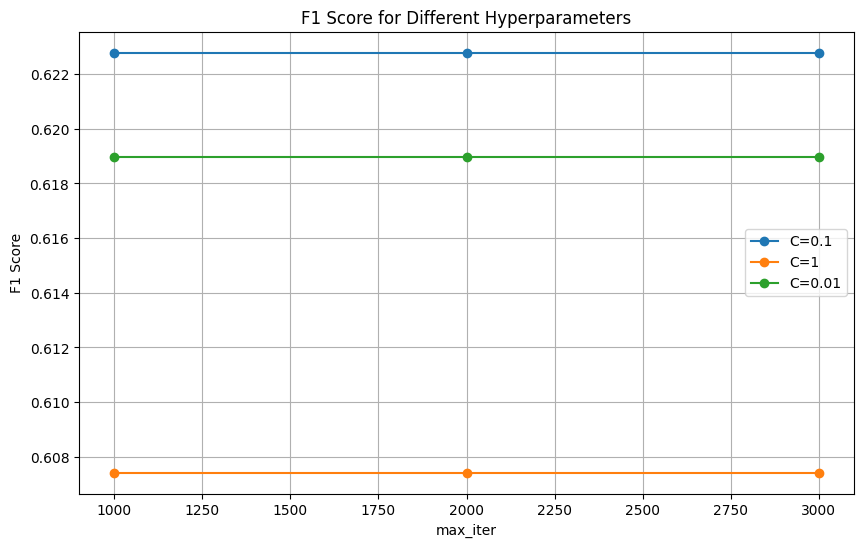

In [ ]:
plot_hyperparameters(f1_scores)

Original

In [ ]:
def perform_LR(X_train, y_train, X_val, y_val):
    # Fixed parameters
    C = 0.1
    max_iter = 1000

    # Train the model with the fixed parameters
    clf = OneVsRestClassifier(LogisticRegression(solver='lbfgs', C=C, max_iter=max_iter))
    clf.fit(X_train, y_train)
    y_val_pred = clf.predict(X_val)

    # Create a classification report
    report = classification_report(y_val, y_val_pred, zero_division=1)
    return report

Original

In [ ]:
X_train, y_train, X_val, y_val, _ = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_original['labels'], val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.60      0.44      0.51       121
           1       0.85      0.73      0.78        55
           2       0.00      0.00      0.00        16
           3       0.41      0.23      0.29        66
           4       1.00      0.00      0.00         2
           5       0.70      0.56      0.62       177
           6       0.51      0.41      0.46       261
           7       1.00      0.00      0.00         6
           8       0.70      0.65      0.68       912
           9       0.55      0.43      0.48        28
          10       1.00      1.00      1.00         0
          11       0.83      0.31      0.45        49
          12       0.46      0.20      0.28       131
          13       1.00      0.00      0.00         1
          14       0.77      0.67      0.71       288
          15       0.70      0.69      0.69       539
          16       0.77      0.67      0.72       113
          17       0.80    

EDA 60%

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_train_eda_60perc.pkl'
X_train, y_train, X_val, y_val, _ = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_eda_60perc['labels'], val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.60      0.43      0.50       121
           1       0.77      0.78      0.77        55
           2       0.00      0.00      0.00        16
           3       0.31      0.17      0.22        66
           4       1.00      0.00      0.00         2
           5       0.72      0.58      0.64       177
           6       0.52      0.40      0.45       261
           7       1.00      0.00      0.00         6
           8       0.71      0.66      0.68       912
           9       0.63      0.43      0.51        28
          10       1.00      1.00      1.00         0
          11       0.80      0.33      0.46        49
          12       0.42      0.21      0.28       131
          13       1.00      0.00      0.00         1
          14       0.78      0.68      0.72       288
          15       0.70      0.69      0.69       539
          16       0.72      0.67      0.70       113
          17       0.79    

Backtranslation (Spanish) 60%

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_train_bt_60perc.pkl'
X_train, y_train, X_val, y_val, _ = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_bt_60perc['labels'], val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.56      0.49      0.52       121
           1       0.86      0.76      0.81        55
           2       0.00      0.00      0.00        16
           3       0.36      0.21      0.27        66
           4       1.00      0.00      0.00         2
           5       0.66      0.56      0.61       177
           6       0.52      0.42      0.47       261
           7       1.00      0.00      0.00         6
           8       0.72      0.67      0.69       912
           9       0.50      0.43      0.46        28
          10       1.00      1.00      1.00         0
          11       0.70      0.33      0.44        49
          12       0.43      0.23      0.30       131
          13       1.00      0.00      0.00         1
          14       0.80      0.68      0.74       288
          15       0.70      0.71      0.71       539
          16       0.74      0.71      0.72       113
          17       0.79    

Backtranslation (Korean) 60%

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_train_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val, _ = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_bt_ko_60perc['labels'], val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.59      0.48      0.53       121
           1       0.86      0.78      0.82        55
           2       0.00      0.00      0.00        16
           3       0.37      0.23      0.28        66
           4       1.00      0.00      0.00         2
           5       0.69      0.60      0.64       177
           6       0.52      0.41      0.46       261
           7       0.00      0.00      0.00         6
           8       0.72      0.67      0.69       912
           9       0.50      0.36      0.42        28
          10       1.00      1.00      1.00         0
          11       0.76      0.33      0.46        49
          12       0.48      0.21      0.30       131
          13       1.00      0.00      0.00         1
          14       0.82      0.68      0.74       288
          15       0.71      0.71      0.71       539
          16       0.77      0.71      0.74       113
          17       0.81    

1% Subset

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset01_original.pkl'
X_train, y_train, X_val, y_val, _ = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset01_original['labels'], val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.36      0.07      0.11       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       0.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       0.87      0.07      0.14       177
           6       0.47      0.03      0.06       261
           7       1.00      0.00      0.00         6
           8       0.56      0.36      0.44       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.33      0.01      0.01       131
          13       1.00      0.00      0.00         1
          14       0.66      0.08      0.14       288
          15       0.64      0.37      0.47       539
          16       1.00      0.00      0.00       113
          17       0.52    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset01_eda_60perc.pkl'
X_train, y_train, X_val, y_val, _ = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset01_eda_60perc['labels'], val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.39      0.09      0.15       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       0.11      0.02      0.03        66
           4       1.00      0.00      0.00         2
           5       0.81      0.10      0.17       177
           6       0.45      0.03      0.06       261
           7       1.00      0.00      0.00         6
           8       0.57      0.38      0.46       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.44      0.03      0.06       131
          13       1.00      0.00      0.00         1
          14       0.64      0.13      0.21       288
          15       0.67      0.41      0.51       539
          16       1.00      0.00      0.00       113
          17       0.53    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset01_bt_60perc.pkl'
X_train, y_train, X_val, y_val, _ = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset01_bt_60perc['labels'], val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.40      0.07      0.11       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       0.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       0.82      0.08      0.14       177
           6       0.44      0.03      0.05       261
           7       1.00      0.00      0.00         6
           8       0.53      0.38      0.45       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.25      0.01      0.01       131
          13       1.00      0.00      0.00         1
          14       0.73      0.11      0.19       288
          15       0.64      0.39      0.48       539
          16       1.00      0.00      0.00       113
          17       0.57    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset01_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val, _ = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset01_bt_ko_60perc['labels'], val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.33      0.07      0.11       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       0.11      0.02      0.03        66
           4       1.00      0.00      0.00         2
           5       0.84      0.09      0.16       177
           6       0.35      0.03      0.06       261
           7       1.00      0.00      0.00         6
           8       0.57      0.39      0.46       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.50      0.02      0.03       131
          13       1.00      0.00      0.00         1
          14       0.65      0.14      0.23       288
          15       0.67      0.42      0.52       539
          16       1.00      0.00      0.00       113
          17       0.57    

5% Subset

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset05_original.pkl'
X_train, y_train, X_val, y_val, _ = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset05_original['labels'], val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.54      0.18      0.27       121
           1       0.90      0.16      0.28        55
           2       1.00      0.00      0.00        16
           3       0.30      0.05      0.08        66
           4       1.00      0.00      0.00         2
           5       0.80      0.34      0.48       177
           6       0.54      0.23      0.33       261
           7       1.00      0.00      0.00         6
           8       0.63      0.56      0.59       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.41      0.05      0.09       131
          13       1.00      0.00      0.00         1
          14       0.81      0.35      0.49       288
          15       0.63      0.57      0.60       539
          16       0.79      0.36      0.50       113
          17       0.73    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset05_eda_60perc.pkl'
X_train, y_train, X_val, y_val, _ = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset05_eda_60perc['labels'], val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.52      0.21      0.30       121
           1       0.92      0.22      0.35        55
           2       1.00      0.00      0.00        16
           3       0.29      0.06      0.10        66
           4       1.00      0.00      0.00         2
           5       0.81      0.33      0.47       177
           6       0.54      0.24      0.33       261
           7       1.00      0.00      0.00         6
           8       0.63      0.56      0.59       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.46      0.09      0.15       131
          13       1.00      0.00      0.00         1
          14       0.76      0.41      0.54       288
          15       0.64      0.57      0.60       539
          16       0.74      0.31      0.44       113
          17       0.67    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset05_bt_60perc.pkl'
X_train, y_train, X_val, y_val, _ = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset05_bt_60perc['labels'], val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.55      0.20      0.29       121
           1       0.90      0.16      0.28        55
           2       1.00      0.00      0.00        16
           3       0.45      0.08      0.13        66
           4       1.00      0.00      0.00         2
           5       0.74      0.35      0.48       177
           6       0.49      0.23      0.32       261
           7       1.00      0.00      0.00         6
           8       0.64      0.57      0.60       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.56      0.08      0.13       131
          13       1.00      0.00      0.00         1
          14       0.76      0.38      0.51       288
          15       0.64      0.56      0.60       539
          16       0.81      0.31      0.45       113
          17       0.70    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset05_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val, _ = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset05_bt_ko_60perc['labels'], val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.55      0.23      0.33       121
           1       0.83      0.18      0.30        55
           2       1.00      0.00      0.00        16
           3       0.24      0.06      0.10        66
           4       1.00      0.00      0.00         2
           5       0.78      0.34      0.48       177
           6       0.53      0.25      0.34       261
           7       1.00      0.00      0.00         6
           8       0.62      0.58      0.60       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.52      0.10      0.17       131
          13       1.00      0.00      0.00         1
          14       0.75      0.41      0.53       288
          15       0.62      0.55      0.58       539
          16       0.80      0.32      0.46       113
          17       0.71    

10% Subset

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset10_original.pkl'
X_train, y_train, X_val, y_val, _ = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset10_original['labels'], val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.70      0.26      0.38       121
           1       0.70      0.38      0.49        55
           2       1.00      0.00      0.00        16
           3       0.38      0.05      0.08        66
           4       1.00      0.00      0.00         2
           5       0.79      0.40      0.53       177
           6       0.51      0.32      0.39       261
           7       1.00      0.00      0.00         6
           8       0.65      0.61      0.63       912
           9       1.00      0.07      0.13        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.45      0.11      0.18       131
          13       1.00      0.00      0.00         1
          14       0.80      0.53      0.64       288
          15       0.68      0.64      0.66       539
          16       0.83      0.60      0.70       113
          17       0.76    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset10_eda_60perc.pkl'
X_train, y_train, X_val, y_val, _ = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset10_eda_60perc['labels'], val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.69      0.31      0.42       121
           1       0.70      0.38      0.49        55
           2       1.00      0.00      0.00        16
           3       0.36      0.08      0.12        66
           4       1.00      0.00      0.00         2
           5       0.70      0.43      0.53       177
           6       0.49      0.31      0.38       261
           7       1.00      0.00      0.00         6
           8       0.62      0.60      0.61       912
           9       1.00      0.14      0.25        28
          10       1.00      1.00      1.00         0
          11       0.00      0.00      0.00        49
          12       0.44      0.14      0.21       131
          13       1.00      0.00      0.00         1
          14       0.79      0.51      0.62       288
          15       0.66      0.61      0.63       539
          16       0.85      0.63      0.72       113
          17       0.74    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset10_bt_60perc.pkl'
X_train, y_train, X_val, y_val, _ = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset10_bt_60perc['labels'], val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.69      0.29      0.41       121
           1       0.72      0.42      0.53        55
           2       1.00      0.00      0.00        16
           3       0.44      0.06      0.11        66
           4       1.00      0.00      0.00         2
           5       0.72      0.42      0.53       177
           6       0.50      0.37      0.43       261
           7       1.00      0.00      0.00         6
           8       0.63      0.58      0.61       912
           9       1.00      0.11      0.19        28
          10       1.00      1.00      1.00         0
          11       1.00      0.02      0.04        49
          12       0.52      0.12      0.20       131
          13       1.00      0.00      0.00         1
          14       0.78      0.53      0.63       288
          15       0.67      0.63      0.65       539
          16       0.84      0.55      0.66       113
          17       0.73    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset10_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val, _ = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset10_bt_ko_60perc['labels'], val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.68      0.28      0.40       121
           1       0.71      0.40      0.51        55
           2       1.00      0.00      0.00        16
           3       0.40      0.06      0.11        66
           4       1.00      0.00      0.00         2
           5       0.80      0.44      0.56       177
           6       0.49      0.36      0.42       261
           7       1.00      0.00      0.00         6
           8       0.63      0.59      0.61       912
           9       0.71      0.18      0.29        28
          10       1.00      1.00      1.00         0
          11       1.00      0.04      0.08        49
          12       0.41      0.11      0.18       131
          13       1.00      0.00      0.00         1
          14       0.78      0.53      0.63       288
          15       0.66      0.64      0.65       539
          16       0.80      0.63      0.70       113
          17       0.74    

20% Subset

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset20_original.pkl'
X_train, y_train, X_val, y_val, _ = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset20_original['labels'], val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.60      0.31      0.40       121
           1       0.82      0.58      0.68        55
           2       1.00      0.00      0.00        16
           3       0.22      0.09      0.13        66
           4       1.00      0.00      0.00         2
           5       0.76      0.44      0.56       177
           6       0.52      0.38      0.44       261
           7       0.00      0.00      0.00         6
           8       0.63      0.63      0.63       912
           9       0.33      0.04      0.06        28
          10       1.00      1.00      1.00         0
          11       0.86      0.12      0.21        49
          12       0.40      0.18      0.24       131
          13       1.00      0.00      0.00         1
          14       0.75      0.65      0.70       288
          15       0.66      0.62      0.64       539
          16       0.80      0.58      0.67       113
          17       0.72    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset20_eda_60perc.pkl'
X_train, y_train, X_val, y_val, _ = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset20_eda_60perc['labels'], val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.62      0.33      0.43       121
           1       0.75      0.60      0.67        55
           2       1.00      0.00      0.00        16
           3       0.21      0.09      0.13        66
           4       1.00      0.00      0.00         2
           5       0.75      0.47      0.58       177
           6       0.55      0.38      0.45       261
           7       0.00      0.00      0.00         6
           8       0.63      0.60      0.61       912
           9       0.43      0.11      0.17        28
          10       1.00      1.00      1.00         0
          11       0.75      0.12      0.21        49
          12       0.45      0.19      0.27       131
          13       1.00      0.00      0.00         1
          14       0.74      0.63      0.68       288
          15       0.65      0.63      0.64       539
          16       0.78      0.58      0.66       113
          17       0.71    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset20_bt_60perc.pkl'
X_train, y_train, X_val, y_val, _ = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset20_bt_60perc['labels'], val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.56      0.31      0.40       121
           1       0.91      0.55      0.68        55
           2       1.00      0.00      0.00        16
           3       0.20      0.09      0.13        66
           4       1.00      0.00      0.00         2
           5       0.72      0.46      0.56       177
           6       0.53      0.39      0.45       261
           7       0.00      0.00      0.00         6
           8       0.64      0.60      0.62       912
           9       0.30      0.11      0.16        28
          10       1.00      1.00      1.00         0
          11       0.88      0.14      0.25        49
          12       0.37      0.17      0.23       131
          13       1.00      0.00      0.00         1
          14       0.76      0.65      0.70       288
          15       0.67      0.64      0.65       539
          16       0.80      0.58      0.67       113
          17       0.70    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset20_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val, _ = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset20_bt_ko_60perc['labels'], val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.58      0.31      0.41       121
           1       0.86      0.56      0.68        55
           2       1.00      0.00      0.00        16
           3       0.19      0.08      0.11        66
           4       1.00      0.00      0.00         2
           5       0.78      0.47      0.58       177
           6       0.52      0.38      0.44       261
           7       0.00      0.00      0.00         6
           8       0.63      0.62      0.62       912
           9       0.36      0.14      0.21        28
          10       1.00      1.00      1.00         0
          11       0.75      0.12      0.21        49
          12       0.37      0.18      0.24       131
          13       1.00      0.00      0.00         1
          14       0.74      0.66      0.70       288
          15       0.67      0.64      0.66       539
          16       0.81      0.60      0.69       113
          17       0.73    

30% Subset

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset30_original.pkl'
X_train, y_train, X_val, y_val, _ = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset30_original['labels'], val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.60      0.30      0.40       121
           1       0.79      0.56      0.66        55
           2       1.00      0.00      0.00        16
           3       0.24      0.09      0.13        66
           4       1.00      0.00      0.00         2
           5       0.76      0.53      0.62       177
           6       0.52      0.36      0.42       261
           7       1.00      0.00      0.00         6
           8       0.65      0.61      0.63       912
           9       0.75      0.11      0.19        28
          10       1.00      1.00      1.00         0
          11       1.00      0.10      0.19        49
          12       0.44      0.16      0.23       131
          13       1.00      0.00      0.00         1
          14       0.79      0.64      0.71       288
          15       0.66      0.67      0.66       539
          16       0.81      0.65      0.72       113
          17       0.76    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset30_eda_60perc.pkl'
X_train, y_train, X_val, y_val, _ = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset30_eda_60perc['labels'], val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.59      0.35      0.44       121
           1       0.84      0.65      0.73        55
           2       1.00      0.00      0.00        16
           3       0.26      0.14      0.18        66
           4       1.00      0.00      0.00         2
           5       0.69      0.49      0.57       177
           6       0.51      0.34      0.41       261
           7       1.00      0.00      0.00         6
           8       0.64      0.63      0.63       912
           9       0.50      0.18      0.26        28
          10       1.00      1.00      1.00         0
          11       1.00      0.14      0.25        49
          12       0.50      0.18      0.27       131
          13       1.00      0.00      0.00         1
          14       0.71      0.61      0.66       288
          15       0.66      0.65      0.66       539
          16       0.79      0.66      0.72       113
          17       0.74    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset30_bt_60perc.pkl'
X_train, y_train, X_val, y_val, _ = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset30_bt_60perc['labels'], val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.58      0.36      0.44       121
           1       0.79      0.56      0.66        55
           2       1.00      0.00      0.00        16
           3       0.26      0.14      0.18        66
           4       1.00      0.00      0.00         2
           5       0.65      0.51      0.57       177
           6       0.50      0.39      0.44       261
           7       1.00      0.00      0.00         6
           8       0.65      0.63      0.64       912
           9       0.62      0.18      0.28        28
          10       1.00      1.00      1.00         0
          11       0.86      0.12      0.21        49
          12       0.45      0.13      0.20       131
          13       1.00      0.00      0.00         1
          14       0.76      0.64      0.69       288
          15       0.64      0.68      0.66       539
          16       0.84      0.65      0.73       113
          17       0.75    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset30_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val, _ = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset30_bt_ko_60perc['labels'], val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.56      0.31      0.40       121
           1       0.80      0.64      0.71        55
           2       1.00      0.00      0.00        16
           3       0.26      0.15      0.19        66
           4       1.00      0.00      0.00         2
           5       0.69      0.48      0.56       177
           6       0.48      0.35      0.40       261
           7       1.00      0.00      0.00         6
           8       0.66      0.64      0.65       912
           9       0.50      0.18      0.26        28
          10       1.00      1.00      1.00         0
          11       0.88      0.14      0.25        49
          12       0.47      0.15      0.22       131
          13       1.00      0.00      0.00         1
          14       0.76      0.64      0.69       288
          15       0.68      0.68      0.68       539
          16       0.83      0.66      0.74       113
          17       0.76    

## Roberta

Hyperparameter tuning

In [ ]:
val_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_val.pkl'
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_train_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_original['labels'], val_df['labels'])
f1_scores = hyperparam_perform_LR(X_train, y_train, X_val, y_val)

Parameters: C= 0.01 , max_iter= 1000  --> F1 score: 0.6485867863270953
Parameters: C= 0.01 , max_iter= 2000  --> F1 score: 0.6485867863270953
Parameters: C= 0.01 , max_iter= 3000  --> F1 score: 0.6485867863270953
Parameters: C= 0.1 , max_iter= 1000  --> F1 score: 0.6453653185767904
Parameters: C= 0.1 , max_iter= 2000  --> F1 score: 0.6453653185767904
Parameters: C= 0.1 , max_iter= 3000  --> F1 score: 0.6453653185767904
Parameters: C= 1 , max_iter= 1000  --> F1 score: 0.6260707793799505
Parameters: C= 1 , max_iter= 2000  --> F1 score: 0.6260707793799505
Parameters: C= 1 , max_iter= 3000  --> F1 score: 0.6260707793799505
Best parameters: C= 0.01 , max_iter= 1000


In [ ]:
def plot_hyperparameters(records):
    C_values = [k[0] for k in records.keys()]
    max_iter_values = [k[1] for k in records.keys()]
    f1_scores = list(records.values())

    plt.figure(figsize=(10,6))

    for c in set(C_values):
        f1_scores_for_c = [f1_scores[i] for i in range(len(C_values)) if C_values[i] == c]
        max_iter_for_c = [max_iter_values[i] for i in range(len(C_values)) if C_values[i] == c]
        plt.plot(max_iter_for_c, f1_scores_for_c, label=f'C={c}', marker='o')

    plt.xlabel('max_iter')
    plt.ylabel('F1 Score')
    plt.title('F1 Score for Different Hyperparameters')
    plt.legend()
    plt.grid(True)
    plt.show()

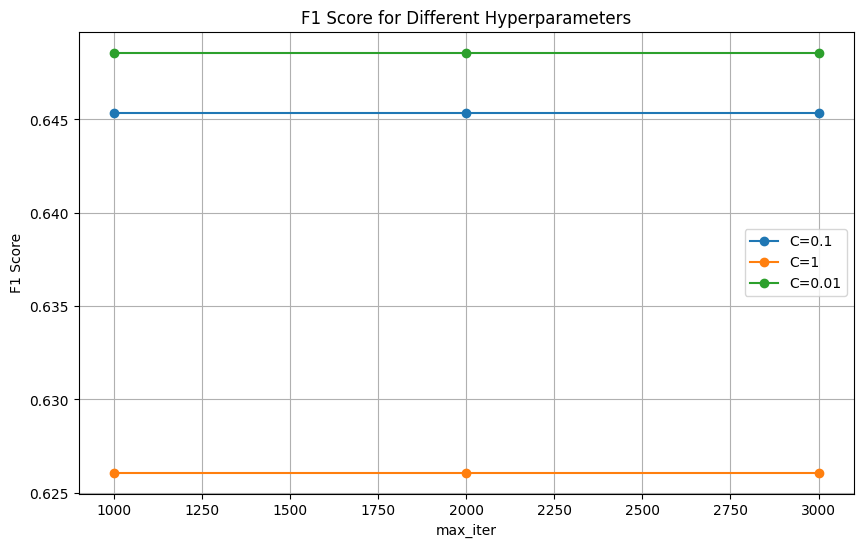

In [ ]:
plot_hyperparameters(f1_scores)

Original

In [ ]:
def perform_LR(X_train, y_train, X_val, y_val):
    # Fixed parameters
    C = 0.01
    max_iter = 1000

    # Train the model with the fixed parameters
    clf = OneVsRestClassifier(LogisticRegression(solver='lbfgs', C=C, max_iter=max_iter))
    clf.fit(X_train, y_train)
    y_val_pred = clf.predict(X_val)

    # Create a classification report
    report = classification_report(y_val, y_val_pred, zero_division=1)
    return report

In [ ]:
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_original['labels'], val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.68      0.40      0.50       121
           1       0.89      0.71      0.79        55
           2       1.00      0.06      0.12        16
           3       0.56      0.15      0.24        66
           4       1.00      0.00      0.00         2
           5       0.84      0.54      0.66       177
           6       0.66      0.38      0.48       261
           7       1.00      0.00      0.00         6
           8       0.71      0.67      0.69       912
           9       0.69      0.32      0.44        28
          10       1.00      1.00      1.00         0
          11       1.00      0.22      0.37        49
          12       0.70      0.23      0.34       131
          13       1.00      0.00      0.00         1
          14       0.87      0.66      0.75       288
          15       0.77      0.72      0.74       539
          16       0.91      0.70      0.79       113
          17       0.83    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_train_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_eda_60perc['labels'], val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.67      0.39      0.49       121
           1       0.87      0.73      0.79        55
           2       0.50      0.06      0.11        16
           3       0.55      0.17      0.26        66
           4       1.00      0.00      0.00         2
           5       0.85      0.55      0.67       177
           6       0.64      0.37      0.47       261
           7       1.00      0.00      0.00         6
           8       0.72      0.67      0.69       912
           9       0.69      0.39      0.50        28
          10       1.00      1.00      1.00         0
          11       0.93      0.27      0.41        49
          12       0.68      0.21      0.32       131
          13       1.00      0.00      0.00         1
          14       0.88      0.67      0.76       288
          15       0.77      0.73      0.75       539
          16       0.92      0.71      0.80       113
          17       0.82    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_train_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_bt_60perc['labels'], val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.67      0.40      0.51       121
           1       0.85      0.75      0.80        55
           2       0.33      0.06      0.11        16
           3       0.59      0.20      0.30        66
           4       1.00      0.00      0.00         2
           5       0.87      0.55      0.67       177
           6       0.59      0.38      0.46       261
           7       1.00      0.00      0.00         6
           8       0.72      0.67      0.70       912
           9       0.74      0.50      0.60        28
          10       1.00      1.00      1.00         0
          11       0.93      0.29      0.44        49
          12       0.71      0.22      0.34       131
          13       1.00      0.00      0.00         1
          14       0.87      0.68      0.76       288
          15       0.77      0.72      0.74       539
          16       0.89      0.72      0.79       113
          17       0.81    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_train_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_bt_ko_60perc['labels'], val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.70      0.40      0.51       121
           1       0.89      0.75      0.81        55
           2       0.50      0.06      0.11        16
           3       0.50      0.15      0.23        66
           4       1.00      0.00      0.00         2
           5       0.84      0.55      0.66       177
           6       0.62      0.40      0.49       261
           7       1.00      0.00      0.00         6
           8       0.70      0.68      0.69       912
           9       0.62      0.46      0.53        28
          10       1.00      1.00      1.00         0
          11       0.93      0.29      0.44        49
          12       0.70      0.23      0.34       131
          13       1.00      0.00      0.00         1
          14       0.90      0.69      0.78       288
          15       0.76      0.72      0.74       539
          16       0.90      0.73      0.80       113
          17       0.84    

1% Subset

In [ ]:
data_size = "subset01"

In [ ]:
# Original
train_pickle_path = f'/content/gdrive/My Drive/MSc Project/roberta_embeddings_{data_size}_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, eval(f"{data_size}_original['labels']"), val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.50      0.01      0.02       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.09      0.17       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.67      0.28      0.39       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       0.81      0.05      0.09       288
          15       0.71      0.24      0.36       539
          16       1.00      0.00      0.00       113
          17       0.77    

In [ ]:
# EDA 60%
train_pickle_path = f'/content/gdrive/My Drive/MSc Project/roberta_embeddings_{data_size}_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, eval(f"{data_size}_eda_60perc['labels']"), val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.33      0.02      0.03       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.11      0.19       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.64      0.31      0.42       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       0.88      0.10      0.19       288
          15       0.69      0.27      0.39       539
          16       1.00      0.00      0.00       113
          17       0.71    

In [ ]:
# BT 60%
train_pickle_path = f'/content/gdrive/My Drive/MSc Project/roberta_embeddings_{data_size}_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, eval(f"{data_size}_bt_60perc['labels']"), val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.33      0.01      0.02       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       0.95      0.12      0.21       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.63      0.31      0.41       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       0.85      0.08      0.15       288
          15       0.71      0.32      0.44       539
          16       1.00      0.00      0.00       113
          17       0.73    

In [ ]:
# BT KO 60%
train_pickle_path = f'/content/gdrive/My Drive/MSc Project/roberta_embeddings_{data_size}_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, eval(f"{data_size}_bt_ko_60perc['labels']"), val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)


              precision    recall  f1-score   support

           0       0.67      0.02      0.03       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       0.96      0.12      0.22       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.67      0.34      0.45       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       0.79      0.13      0.22       288
          15       0.71      0.30      0.42       539
          16       1.00      0.00      0.00       113
          17       0.76    

5% Subset

In [ ]:
data_size = 'subset05'

In [ ]:
# Original
train_pickle_path = f'/content/gdrive/My Drive/MSc Project/roberta_embeddings_{data_size}_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, eval(f"{data_size}_original['labels']"), val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.61      0.12      0.19       121
           1       1.00      0.04      0.07        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       0.93      0.23      0.37       177
           6       0.78      0.11      0.19       261
           7       1.00      0.00      0.00         6
           8       0.71      0.55      0.62       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.50      0.02      0.03       131
          13       1.00      0.00      0.00         1
          14       0.90      0.27      0.42       288
          15       0.77      0.52      0.62       539
          16       0.94      0.13      0.23       113
          17       0.78    

In [ ]:
# EDA 60%
train_pickle_path = f'/content/gdrive/My Drive/MSc Project/roberta_embeddings_{data_size}_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, eval(f"{data_size}_eda_60perc['labels']"), val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.67      0.17      0.26       121
           1       1.00      0.11      0.20        55
           2       1.00      0.00      0.00        16
           3       0.50      0.03      0.06        66
           4       1.00      0.00      0.00         2
           5       0.92      0.25      0.39       177
           6       0.76      0.13      0.23       261
           7       1.00      0.00      0.00         6
           8       0.68      0.55      0.61       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.67      0.03      0.06       131
          13       1.00      0.00      0.00         1
          14       0.84      0.33      0.47       288
          15       0.75      0.53      0.62       539
          16       0.89      0.14      0.24       113
          17       0.78    

In [ ]:
# BT 60%
train_pickle_path = f'/content/gdrive/My Drive/MSc Project/roberta_embeddings_{data_size}_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, eval(f"{data_size}_bt_60perc['labels']"), val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.62      0.13      0.22       121
           1       0.89      0.15      0.25        55
           2       1.00      0.00      0.00        16
           3       0.50      0.03      0.06        66
           4       1.00      0.00      0.00         2
           5       0.88      0.30      0.45       177
           6       0.74      0.11      0.19       261
           7       1.00      0.00      0.00         6
           8       0.69      0.55      0.61       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.60      0.02      0.04       131
          13       1.00      0.00      0.00         1
          14       0.86      0.33      0.48       288
          15       0.77      0.55      0.64       539
          16       0.87      0.12      0.20       113
          17       0.76    

In [ ]:
# BT KO 60%
train_pickle_path = f'/content/gdrive/My Drive/MSc Project/roberta_embeddings_{data_size}_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, eval(f"{data_size}_bt_ko_60perc['labels']"), val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.65      0.17      0.26       121
           1       0.90      0.16      0.28        55
           2       1.00      0.00      0.00        16
           3       0.40      0.03      0.06        66
           4       1.00      0.00      0.00         2
           5       0.92      0.32      0.47       177
           6       0.71      0.12      0.21       261
           7       1.00      0.00      0.00         6
           8       0.70      0.56      0.62       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.67      0.03      0.06       131
          13       1.00      0.00      0.00         1
          14       0.86      0.36      0.50       288
          15       0.74      0.53      0.62       539
          16       0.88      0.13      0.23       113
          17       0.78    

10% Subset

In [ ]:
data_size = 'subset10'

In [ ]:
# Original
train_pickle_path = f'/content/gdrive/My Drive/MSc Project/roberta_embeddings_{data_size}_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, eval(f"{data_size}_original['labels']"), val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

# EDA 60%
train_pickle_path = f'/content/gdrive/My Drive/MSc Project/roberta_embeddings_{data_size}_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, eval(f"{data_size}_eda_60perc['labels']"), val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

# BT 60%
train_pickle_path = f'/content/gdrive/My Drive/MSc Project/roberta_embeddings_{data_size}_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, eval(f"{data_size}_bt_60perc['labels']"), val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

# BT KO 60%
train_pickle_path = f'/content/gdrive/My Drive/MSc Project/roberta_embeddings_{data_size}_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, eval(f"{data_size}_bt_ko_60perc['labels']"), val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.62      0.20      0.30       121
           1       0.88      0.27      0.42        55
           2       1.00      0.00      0.00        16
           3       0.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       0.81      0.36      0.50       177
           6       0.61      0.20      0.30       261
           7       1.00      0.00      0.00         6
           8       0.70      0.60      0.65       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.50      0.03      0.06       131
          13       1.00      0.00      0.00         1
          14       0.89      0.46      0.60       288
          15       0.75      0.62      0.68       539
          16       0.87      0.36      0.51       113
          17       0.82    

20% Subset

In [ ]:
data_size = 'subset20'

In [ ]:
# Original
train_pickle_path = f'/content/gdrive/My Drive/MSc Project/roberta_embeddings_{data_size}_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, eval(f"{data_size}_original['labels']"), val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

# EDA 60%
train_pickle_path = f'/content/gdrive/My Drive/MSc Project/roberta_embeddings_{data_size}_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, eval(f"{data_size}_eda_60perc['labels']"), val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

# BT 60%
train_pickle_path = f'/content/gdrive/My Drive/MSc Project/roberta_embeddings_{data_size}_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, eval(f"{data_size}_bt_60perc['labels']"), val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

# BT KO 60%
train_pickle_path = f'/content/gdrive/My Drive/MSc Project/roberta_embeddings_{data_size}_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, eval(f"{data_size}_bt_ko_60perc['labels']"), val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.58      0.25      0.35       121
           1       0.96      0.47      0.63        55
           2       1.00      0.00      0.00        16
           3       0.50      0.02      0.03        66
           4       1.00      0.00      0.00         2
           5       0.87      0.42      0.57       177
           6       0.64      0.29      0.40       261
           7       1.00      0.00      0.00         6
           8       0.71      0.60      0.65       912
           9       0.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.04      0.08        49
          12       0.77      0.08      0.14       131
          13       1.00      0.00      0.00         1
          14       0.91      0.56      0.69       288
          15       0.76      0.68      0.72       539
          16       0.87      0.51      0.64       113
          17       0.82    

 30% Subset

In [ ]:
data_size = 'subset30'

In [ ]:
# Original
train_pickle_path = f'/content/gdrive/My Drive/MSc Project/roberta_embeddings_{data_size}_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, eval(f"{data_size}_original['labels']"), val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

# EDA 60%
train_pickle_path = f'/content/gdrive/My Drive/MSc Project/roberta_embeddings_{data_size}_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, eval(f"{data_size}_eda_60perc['labels']"), val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

# BT 60%
train_pickle_path = f'/content/gdrive/My Drive/MSc Project/roberta_embeddings_{data_size}_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, eval(f"{data_size}_bt_60perc['labels']"), val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

# BT KO 60%
train_pickle_path = f'/content/gdrive/My Drive/MSc Project/roberta_embeddings_{data_size}_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, eval(f"{data_size}_bt_ko_60perc['labels']"), val_df['labels'])
report = perform_LR(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.61      0.29      0.39       121
           1       0.88      0.55      0.67        55
           2       1.00      0.00      0.00        16
           3       0.75      0.09      0.16        66
           4       1.00      0.00      0.00         2
           5       0.92      0.46      0.61       177
           6       0.69      0.33      0.45       261
           7       1.00      0.00      0.00         6
           8       0.71      0.65      0.68       912
           9       1.00      0.04      0.07        28
          10       1.00      1.00      1.00         0
          11       1.00      0.06      0.12        49
          12       0.67      0.15      0.25       131
          13       1.00      0.00      0.00         1
          14       0.86      0.57      0.69       288
          15       0.75      0.69      0.72       539
          16       0.87      0.59      0.71       113
          17       0.83    

## Support Vector Machines (SVM)

Hyperparameter Tuning

In [ ]:
def load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_labels, val_labels):
    with open(train_pickle_path, "rb") as f_train:
        train_data = pickle.load(f_train)
        X_train = train_data['embeddings']

    with open(val_pickle_path, "rb") as f_val:
        val_data = pickle.load(f_val)
        X_val = val_data['embeddings']

    mlb = MultiLabelBinarizer()
    y_train = mlb.fit_transform(train_labels.apply(ast.literal_eval))
    y_val = mlb.transform(val_labels.apply(ast.literal_eval))

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    return X_train, y_train, X_val, y_val

def hyperparam_perform_SVM(X_train, y_train, X_val, y_val):
    C_params = [0.1, 1, 10]
    max_iter_params = [500, 1000, 2000]

    records = {}

    for c in C_params:
        for max_iter in max_iter_params:
            clf = OneVsRestClassifier(SVC(C=c, max_iter=max_iter))
            clf.fit(X_train, y_train)
            y_val_pred = clf.predict(X_val)
            f1score_val = f1_score(y_val, y_val_pred, average='samples')
            records[(c, max_iter)] = f1score_val
            print("Parameters: C=", c, ", max_iter=", max_iter, " --> F1 score:", f1score_val)

    best_params = max(records, key=records.get)
    print("Best parameters: C=", best_params[0], ", max_iter=", best_params[1])

    return records

## Bert

In [ ]:
val_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_val.pkl'

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_train_original.pkl'
X_train, y_train, X_val, y_val, mlb = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_original['labels'], val_df['labels'])
f1_scores = hyperparam_perform_SVM(X_train, y_train, X_val, y_val)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-

Parameters: C= 0.1 , max_iter= 500  --> F1 score: 0.5182804816432298


/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider

Parameters: C= 0.1 , max_iter= 1000  --> F1 score: 0.5001110560833221


/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


...

Parameters: C= 10 , max_iter= 500  --> F1 score: 0.5977516145653554


/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider

Parameters: C= 10 , max_iter= 1000  --> F1 score: 0.6386129995647802


/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider

Parameters: C= 10 , max_iter= 2000  --> F1 score: 0.639015202677352
Best parameters: C= 10 , max_iter= 2000


In [ ]:
def plot_hyperparameters(records):
    C_values = [k[0] for k in records.keys()]
    max_iter_values = [k[1] for k in records.keys()]
    f1_scores = list(records.values())

    plt.figure(figsize=(10,6))

    for c in set(C_values):
        f1_scores_for_c = [f1_scores[i] for i in range(len(C_values)) if C_values[i] == c]
        max_iter_for_c = [max_iter_values[i] for i in range(len(C_values)) if C_values[i] == c]
        plt.plot(max_iter_for_c, f1_scores_for_c, label=f'C={c}', marker='o')

    plt.xlabel('max_iter')
    plt.ylabel('F1 Score')
    plt.title('F1 Score for Different Hyperparameters')
    plt.legend()
    plt.grid(True)
    plt.show()

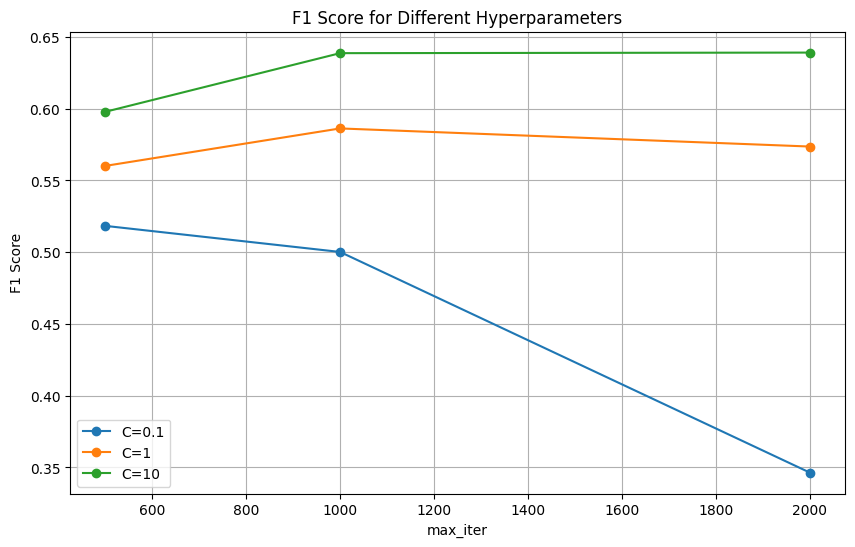

In [ ]:
plot_hyperparameters(f1_scores)

Original

In [ ]:
def perform_SVM(X_train, y_train, X_val, y_val):
    # Fixed parameters
    C = 10
    max_iter = 2000

    # Train the model with the fixed parameters
    clf = OneVsRestClassifier(SVC(C=C, max_iter=max_iter))
    clf.fit(X_train, y_train)
    y_val_pred = clf.predict(X_val)

    # Create a classification report
    report = classification_report(y_val, y_val_pred, zero_division=1)
    return report

In [ ]:
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_original['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider

              precision    recall  f1-score   support

           0       0.71      0.42      0.53       121
           1       0.88      0.69      0.78        55
           2       1.00      0.00      0.00        16
           3       0.35      0.11      0.16        66
           4       1.00      0.00      0.00         2
           5       0.81      0.54      0.64       177
           6       0.62      0.44      0.51       261
           7       1.00      0.00      0.00         6
           8       0.74      0.69      0.71       912
           9       0.77      0.36      0.49        28
          10       1.00      1.00      1.00         0
          11       0.94      0.31      0.46        49
          12       0.71      0.21      0.32       131
          13       1.00      0.00      0.00         1
          14       0.89      0.67      0.77       288
          15       0.75      0.71      0.73       539
          16       0.88      0.66      0.76       113
          17       0.84    

EDA 60%

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_train_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_eda_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider

              precision    recall  f1-score   support

           0       0.72      0.40      0.52       121
           1       0.89      0.73      0.80        55
           2       1.00      0.00      0.00        16
           3       0.39      0.11      0.17        66
           4       1.00      0.00      0.00         2
           5       0.82      0.53      0.64       177
           6       0.62      0.41      0.50       261
           7       1.00      0.00      0.00         6
           8       0.71      0.71      0.71       912
           9       0.69      0.32      0.44        28
          10       1.00      1.00      1.00         0
          11       0.93      0.29      0.44        49
          12       0.76      0.21      0.33       131
          13       1.00      0.00      0.00         1
          14       0.89      0.66      0.76       288
          15       0.73      0.70      0.72       539
          16       0.90      0.65      0.75       113
          17       0.83    

Backtranslation (Spanish) 60%

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_train_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_bt_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider

              precision    recall  f1-score   support

           0       0.77      0.44      0.56       121
           1       0.95      0.69      0.80        55
           2       1.00      0.00      0.00        16
           3       0.47      0.12      0.19        66
           4       1.00      0.00      0.00         2
           5       0.81      0.52      0.63       177
           6       0.62      0.42      0.50       261
           7       1.00      0.00      0.00         6
           8       0.73      0.67      0.70       912
           9       0.64      0.25      0.36        28
          10       1.00      1.00      1.00         0
          11       0.93      0.29      0.44        49
          12       0.70      0.18      0.28       131
          13       1.00      0.00      0.00         1
          14       0.90      0.67      0.77       288
          15       0.75      0.71      0.73       539
          16       0.92      0.69      0.79       113
          17       0.82    

Backtranslation (Korean) 60%

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_train_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_bt_ko_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider

              precision    recall  f1-score   support

           0       0.72      0.44      0.54       121
           1       0.89      0.71      0.79        55
           2       1.00      0.00      0.00        16
           3       0.32      0.11      0.16        66
           4       1.00      0.00      0.00         2
           5       0.79      0.50      0.61       177
           6       0.56      0.39      0.46       261
           7       1.00      0.00      0.00         6
           8       0.71      0.67      0.69       912
           9       0.73      0.29      0.41        28
          10       1.00      1.00      1.00         0
          11       0.93      0.29      0.44        49
          12       0.70      0.23      0.34       131
          13       1.00      0.00      0.00         1
          14       0.89      0.69      0.78       288
          15       0.75      0.73      0.74       539
          16       0.88      0.69      0.77       113
          17       0.83    

1% Subset

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset01_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset01_original['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.29      0.05      0.08       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       0.17      0.03      0.05        66
           4       1.00      0.00      0.00         2
           5       1.00      0.01      0.01       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.59      0.21      0.31       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.01      0.02       131
          13       1.00      0.00      0.00         1
          14       1.00      0.00      0.00       288
          15       0.69      0.25      0.37       539
          16       1.00      0.00      0.00       113
          17       0.67    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset01_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset01_eda_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.27      0.05      0.08       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       0.11      0.03      0.05        66
           4       1.00      0.00      0.00         2
           5       1.00      0.03      0.05       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.59      0.22      0.32       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.80      0.03      0.06       131
          13       1.00      0.00      0.00         1
          14       1.00      0.00      0.00       288
          15       0.71      0.27      0.39       539
          16       1.00      0.00      0.00       113
          17       0.65    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset01_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset01_bt_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.32      0.05      0.09       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       0.12      0.03      0.05        66
           4       1.00      0.00      0.00         2
           5       1.00      0.02      0.03       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.57      0.24      0.34       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.50      0.01      0.02       131
          13       1.00      0.00      0.00         1
          14       1.00      0.00      0.01       288
          15       0.69      0.26      0.38       539
          16       1.00      0.00      0.00       113
          17       0.72    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset01_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset01_bt_ko_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.33      0.07      0.11       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       0.17      0.05      0.07        66
           4       1.00      0.00      0.00         2
           5       1.00      0.01      0.02       177
           6       0.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.59      0.26      0.36       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.01      0.02       131
          13       1.00      0.00      0.00         1
          14       1.00      0.01      0.01       288
          15       0.69      0.32      0.44       539
          16       1.00      0.00      0.00       113
          17       0.70    

5% Subset

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset05_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset05_original['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.81      0.11      0.19       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       0.20      0.02      0.03        66
           4       1.00      0.00      0.00         2
           5       0.96      0.14      0.24       177
           6       0.56      0.15      0.23       261
           7       1.00      0.00      0.00         6
           8       0.71      0.48      0.57       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.50      0.03      0.06       131
          13       1.00      0.00      0.00         1
          14       0.92      0.19      0.32       288
          15       0.71      0.48      0.58       539
          16       0.92      0.21      0.35       113
          17       0.82    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset05_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset05_eda_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.85      0.09      0.16       121
           1       1.00      0.04      0.07        55
           2       1.00      0.00      0.00        16
           3       0.20      0.02      0.03        66
           4       1.00      0.00      0.00         2
           5       0.96      0.14      0.25       177
           6       0.57      0.15      0.24       261
           7       1.00      0.00      0.00         6
           8       0.71      0.48      0.57       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.50      0.04      0.07       131
          13       1.00      0.00      0.00         1
          14       0.93      0.24      0.38       288
          15       0.71      0.47      0.57       539
          16       0.92      0.21      0.35       113
          17       0.81    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset05_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset05_bt_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.72      0.11      0.19       121
           1       1.00      0.02      0.04        55
           2       1.00      0.00      0.00        16
           3       0.38      0.05      0.08        66
           4       1.00      0.00      0.00         2
           5       0.97      0.19      0.31       177
           6       0.56      0.15      0.24       261
           7       1.00      0.00      0.00         6
           8       0.71      0.48      0.57       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.50      0.03      0.06       131
          13       1.00      0.00      0.00         1
          14       0.93      0.22      0.35       288
          15       0.72      0.50      0.59       539
          16       0.92      0.20      0.33       113
          17       0.80    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset05_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset05_bt_ko_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.69      0.15      0.24       121
           1       1.00      0.02      0.04        55
           2       1.00      0.00      0.00        16
           3       0.30      0.05      0.08        66
           4       1.00      0.00      0.00         2
           5       0.97      0.16      0.27       177
           6       0.57      0.16      0.25       261
           7       1.00      0.00      0.00         6
           8       0.70      0.48      0.57       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.62      0.04      0.07       131
          13       1.00      0.00      0.00         1
          14       0.91      0.24      0.38       288
          15       0.71      0.48      0.57       539
          16       0.91      0.19      0.31       113
          17       0.82    

10% Subset

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset10_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset10_original['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.74      0.21      0.33       121
           1       0.90      0.16      0.28        55
           2       1.00      0.00      0.00        16
           3       0.50      0.05      0.08        66
           4       1.00      0.00      0.00         2
           5       0.95      0.24      0.38       177
           6       0.62      0.25      0.35       261
           7       1.00      0.00      0.00         6
           8       0.71      0.56      0.62       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.02      0.04        49
          12       0.67      0.11      0.18       131
          13       1.00      0.00      0.00         1
          14       0.95      0.36      0.53       288
          15       0.74      0.60      0.66       539
          16       0.94      0.44      0.60       113
          17       0.82    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset10_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset10_eda_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.73      0.18      0.29       121
           1       0.71      0.18      0.29        55
           2       1.00      0.00      0.00        16
           3       0.43      0.05      0.08        66
           4       1.00      0.00      0.00         2
           5       0.89      0.27      0.41       177
           6       0.63      0.23      0.34       261
           7       1.00      0.00      0.00         6
           8       0.70      0.55      0.62       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       0.00      0.00      0.00        49
          12       0.67      0.11      0.18       131
          13       1.00      0.00      0.00         1
          14       0.94      0.36      0.53       288
          15       0.74      0.60      0.66       539
          16       0.95      0.48      0.64       113
          17       0.82    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset10_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset10_bt_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.72      0.23      0.35       121
           1       0.83      0.27      0.41        55
           2       1.00      0.00      0.00        16
           3       0.50      0.05      0.08        66
           4       1.00      0.00      0.00         2
           5       0.94      0.25      0.40       177
           6       0.61      0.25      0.35       261
           7       1.00      0.00      0.00         6
           8       0.73      0.55      0.63       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.04      0.08        49
          12       0.57      0.06      0.11       131
          13       1.00      0.00      0.00         1
          14       0.95      0.39      0.55       288
          15       0.76      0.61      0.68       539
          16       0.94      0.45      0.61       113
          17       0.81    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset10_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset10_bt_ko_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.73      0.20      0.31       121
           1       0.92      0.22      0.35        55
           2       1.00      0.00      0.00        16
           3       0.38      0.05      0.08        66
           4       1.00      0.00      0.00         2
           5       0.93      0.28      0.43       177
           6       0.55      0.24      0.33       261
           7       1.00      0.00      0.00         6
           8       0.71      0.56      0.62       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.02      0.04        49
          12       0.56      0.08      0.13       131
          13       1.00      0.00      0.00         1
          14       0.93      0.39      0.55       288
          15       0.74      0.61      0.67       539
          16       0.95      0.47      0.63       113
          17       0.82    

20% Subset

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset20_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset20_original['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.64      0.22      0.33       121
           1       1.00      0.40      0.57        55
           2       1.00      0.00      0.00        16
           3       0.25      0.05      0.08        66
           4       1.00      0.00      0.00         2
           5       0.92      0.37      0.52       177
           6       0.61      0.34      0.43       261
           7       1.00      0.00      0.00         6
           8       0.69      0.57      0.62       912
           9       0.50      0.07      0.12        28
          10       1.00      1.00      1.00         0
          11       1.00      0.08      0.15        49
          12       0.46      0.08      0.14       131
          13       1.00      0.00      0.00         1
          14       0.86      0.50      0.63       288
          15       0.76      0.61      0.68       539
          16       0.92      0.50      0.65       113
          17       0.83    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset20_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset20_eda_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider

              precision    recall  f1-score   support

           0       0.70      0.23      0.35       121
           1       1.00      0.42      0.59        55
           2       1.00      0.00      0.00        16
           3       0.23      0.05      0.08        66
           4       1.00      0.00      0.00         2
           5       0.90      0.37      0.52       177
           6       0.61      0.31      0.41       261
           7       1.00      0.00      0.00         6
           8       0.70      0.57      0.63       912
           9       0.50      0.04      0.07        28
          10       1.00      1.00      1.00         0
          11       1.00      0.06      0.12        49
          12       0.43      0.08      0.13       131
          13       1.00      0.00      0.00         1
          14       0.85      0.49      0.62       288
          15       0.76      0.61      0.68       539
          16       0.90      0.54      0.67       113
          17       0.82    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset20_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset20_bt_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.61      0.22      0.33       121
           1       1.00      0.40      0.57        55
           2       1.00      0.00      0.00        16
           3       0.30      0.05      0.08        66
           4       1.00      0.00      0.00         2
           5       0.92      0.38      0.54       177
           6       0.60      0.35      0.44       261
           7       1.00      0.00      0.00         6
           8       0.70      0.56      0.62       912
           9       0.25      0.04      0.06        28
          10       1.00      1.00      1.00         0
          11       1.00      0.10      0.19        49
          12       0.41      0.07      0.12       131
          13       1.00      0.00      0.00         1
          14       0.86      0.50      0.63       288
          15       0.76      0.62      0.68       539
          16       0.94      0.53      0.68       113
          17       0.82    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset20_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset20_bt_ko_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider

              precision    recall  f1-score   support

           0       0.64      0.25      0.36       121
           1       1.00      0.42      0.59        55
           2       1.00      0.00      0.00        16
           3       0.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       0.90      0.36      0.52       177
           6       0.58      0.33      0.42       261
           7       1.00      0.00      0.00         6
           8       0.70      0.58      0.63       912
           9       0.50      0.04      0.07        28
          10       1.00      1.00      1.00         0
          11       1.00      0.12      0.22        49
          12       0.35      0.06      0.10       131
          13       1.00      0.00      0.00         1
          14       0.83      0.51      0.63       288
          15       0.76      0.62      0.68       539
          16       0.92      0.51      0.66       113
          17       0.83    

30% Subset

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset30_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset30_original['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider

              precision    recall  f1-score   support

           0       0.61      0.29      0.39       121
           1       0.96      0.45      0.62        55
           2       1.00      0.00      0.00        16
           3       0.21      0.05      0.08        66
           4       1.00      0.00      0.00         2
           5       0.86      0.39      0.54       177
           6       0.62      0.33      0.43       261
           7       1.00      0.00      0.00         6
           8       0.72      0.61      0.66       912
           9       0.60      0.11      0.18        28
          10       1.00      1.00      1.00         0
          11       1.00      0.16      0.28        49
          12       0.58      0.11      0.19       131
          13       1.00      0.00      0.00         1
          14       0.83      0.56      0.67       288
          15       0.74      0.65      0.69       539
          16       0.94      0.58      0.72       113
          17       0.83    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset30_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset30_eda_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider

              precision    recall  f1-score   support

           0       0.70      0.31      0.43       121
           1       1.00      0.49      0.66        55
           2       1.00      0.00      0.00        16
           3       0.27      0.06      0.10        66
           4       1.00      0.00      0.00         2
           5       0.90      0.41      0.56       177
           6       0.64      0.32      0.43       261
           7       1.00      0.00      0.00         6
           8       0.72      0.61      0.66       912
           9       0.60      0.11      0.18        28
          10       1.00      1.00      1.00         0
          11       0.89      0.16      0.28        49
          12       0.62      0.14      0.23       131
          13       1.00      0.00      0.00         1
          14       0.83      0.54      0.66       288
          15       0.75      0.64      0.69       539
          16       0.95      0.64      0.76       113
          17       0.84    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset30_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset30_bt_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider

              precision    recall  f1-score   support

           0       0.66      0.31      0.42       121
           1       0.96      0.47      0.63        55
           2       1.00      0.00      0.00        16
           3       0.27      0.05      0.08        66
           4       1.00      0.00      0.00         2
           5       0.88      0.42      0.57       177
           6       0.61      0.34      0.44       261
           7       1.00      0.00      0.00         6
           8       0.70      0.59      0.64       912
           9       0.80      0.14      0.24        28
          10       1.00      1.00      1.00         0
          11       1.00      0.14      0.25        49
          12       0.67      0.09      0.16       131
          13       1.00      0.00      0.00         1
          14       0.84      0.55      0.66       288
          15       0.74      0.67      0.71       539
          16       0.94      0.58      0.72       113
          17       0.82    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset30_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset30_bt_ko_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider

              precision    recall  f1-score   support

           0       0.63      0.33      0.43       121
           1       0.97      0.55      0.70        55
           2       1.00      0.00      0.00        16
           3       0.27      0.09      0.14        66
           4       1.00      0.00      0.00         2
           5       0.84      0.38      0.53       177
           6       0.61      0.33      0.43       261
           7       1.00      0.00      0.00         6
           8       0.70      0.63      0.66       912
           9       0.62      0.18      0.28        28
          10       1.00      1.00      1.00         0
          11       1.00      0.18      0.31        49
          12       0.61      0.11      0.18       131
          13       1.00      0.00      0.00         1
          14       0.83      0.57      0.67       288
          15       0.76      0.65      0.70       539
          16       0.95      0.61      0.74       113
          17       0.84    

## Roberta

Hyperparameter Tuning

In [ ]:
val_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_val.pkl'

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_train_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_original['labels'], val_df['labels'])
f1_scores = hyperparam_perform_SVM(X_train, y_train, X_val, y_val)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-

Parameters: C= 0.1 , max_iter= 500  --> F1 score: 0.5299377094523644


/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider

Parameters: C= 0.1 , max_iter= 1000  --> F1 score: 0.5075525640448426


/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


...

Parameters: C= 10 , max_iter= 500  --> F1 score: 0.6288065700451455


/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider

Parameters: C= 10 , max_iter= 1000  --> F1 score: 0.661916858922847


/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider

Parameters: C= 10 , max_iter= 2000  --> F1 score: 0.6603070459673044
Best parameters: C= 10 , max_iter= 1000


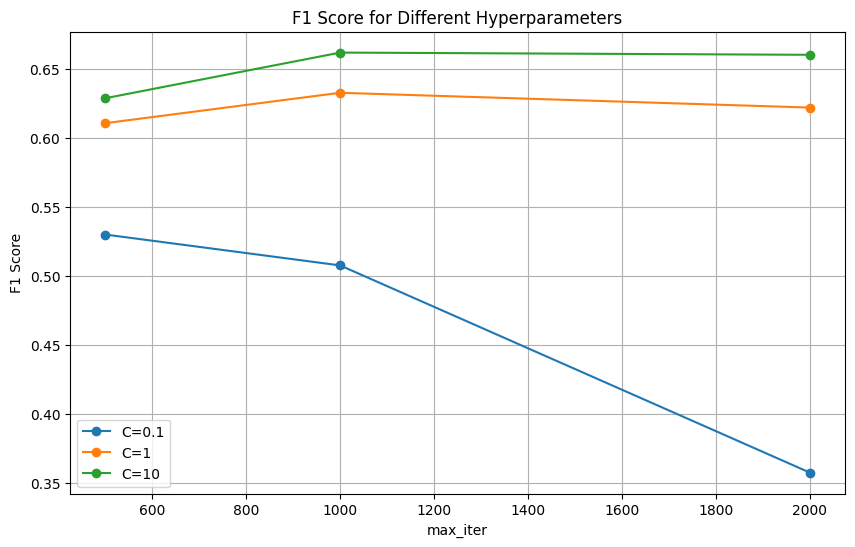

In [ ]:
plot_hyperparameters(f1_scores)

Original

In [ ]:
def perform_SVM(X_train, y_train, X_val, y_val):
    # Fixed parameters
    C = 10
    max_iter = 1000

    # Train the model with the fixed parameters
    clf = OneVsRestClassifier(SVC(C=C, max_iter=max_iter))
    clf.fit(X_train, y_train)
    y_val_pred = clf.predict(X_val)

    # Create a classification report
    report = classification_report(y_val, y_val_pred, zero_division=1)
    return report

In [ ]:
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_original['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider

              precision    recall  f1-score   support

           0       0.75      0.45      0.56       121
           1       0.86      0.76      0.81        55
           2       1.00      0.00      0.00        16
           3       0.63      0.18      0.28        66
           4       1.00      0.00      0.00         2
           5       0.82      0.54      0.65       177
           6       0.60      0.39      0.47       261
           7       1.00      0.00      0.00         6
           8       0.69      0.71      0.70       912
           9       0.64      0.25      0.36        28
          10       1.00      1.00      1.00         0
          11       1.00      0.24      0.39        49
          12       0.74      0.28      0.41       131
          13       1.00      0.00      0.00         1
          14       0.88      0.67      0.76       288
          15       0.78      0.76      0.77       539
          16       0.95      0.67      0.79       113
          17       0.82    

EDA 60%

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_train_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_eda_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider

              precision    recall  f1-score   support

           0       0.75      0.45      0.56       121
           1       0.88      0.76      0.82        55
           2       1.00      0.00      0.00        16
           3       0.62      0.20      0.30        66
           4       1.00      0.00      0.00         2
           5       0.78      0.55      0.65       177
           6       0.63      0.40      0.49       261
           7       1.00      0.00      0.00         6
           8       0.66      0.69      0.67       912
           9       0.64      0.25      0.36        28
          10       1.00      1.00      1.00         0
          11       1.00      0.20      0.34        49
          12       0.81      0.29      0.43       131
          13       1.00      0.00      0.00         1
          14       0.85      0.68      0.76       288
          15       0.78      0.77      0.77       539
          16       0.92      0.69      0.79       113
          17       0.77    

Backtranslation (Spanish) 60%

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_train_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_bt_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider

              precision    recall  f1-score   support

           0       0.71      0.45      0.56       121
           1       0.89      0.71      0.79        55
           2       1.00      0.00      0.00        16
           3       0.58      0.17      0.26        66
           4       1.00      0.00      0.00         2
           5       0.83      0.54      0.66       177
           6       0.63      0.46      0.53       261
           7       1.00      0.00      0.00         6
           8       0.65      0.71      0.68       912
           9       0.62      0.29      0.39        28
          10       1.00      1.00      1.00         0
          11       0.92      0.24      0.39        49
          12       0.75      0.27      0.40       131
          13       1.00      0.00      0.00         1
          14       0.87      0.68      0.76       288
          15       0.76      0.75      0.75       539
          16       0.95      0.71      0.81       113
          17       0.79    

Backtranslation (Korean) 60%

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_train_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_bt_ko_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider

              precision    recall  f1-score   support

           0       0.78      0.50      0.61       121
           1       0.90      0.78      0.83        55
           2       1.00      0.00      0.00        16
           3       0.61      0.17      0.26        66
           4       1.00      0.00      0.00         2
           5       0.79      0.56      0.66       177
           6       0.65      0.42      0.51       261
           7       1.00      0.00      0.00         6
           8       0.64      0.73      0.68       912
           9       0.71      0.36      0.48        28
          10       1.00      1.00      1.00         0
          11       0.92      0.24      0.39        49
          12       0.72      0.31      0.44       131
          13       1.00      0.00      0.00         1
          14       0.86      0.71      0.78       288
          15       0.73      0.76      0.75       539
          16       0.96      0.68      0.80       113
          17       0.79    

1% Subset

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset01_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset01_original['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.50      0.03      0.06       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       0.14      0.02      0.03        66
           4       1.00      0.00      0.00         2
           5       1.00      0.00      0.00       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.66      0.21      0.32       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.01      0.02       131
          13       1.00      0.00      0.00         1
          14       1.00      0.01      0.03       288
          15       0.75      0.25      0.37       539
          16       1.00      0.00      0.00       113
          17       0.84    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset01_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset01_eda_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.54      0.06      0.10       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       0.12      0.02      0.03        66
           4       1.00      0.00      0.00         2
           5       1.00      0.00      0.00       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.68      0.22      0.33       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.01      0.02       131
          13       1.00      0.00      0.00         1
          14       1.00      0.02      0.04       288
          15       0.76      0.26      0.39       539
          16       1.00      0.00      0.00       113
          17       0.84    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset01_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset01_bt_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.57      0.03      0.06       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       0.12      0.02      0.03        66
           4       1.00      0.00      0.00         2
           5       1.00      0.03      0.05       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.66      0.26      0.37       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.01      0.02       131
          13       1.00      0.00      0.00         1
          14       1.00      0.02      0.04       288
          15       0.74      0.36      0.48       539
          16       1.00      0.00      0.00       113
          17       0.82    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset01_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset01_bt_ko_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.62      0.04      0.08       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       0.12      0.02      0.03        66
           4       1.00      0.00      0.00         2
           5       1.00      0.02      0.03       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.68      0.24      0.35       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.01      0.02       131
          13       1.00      0.00      0.00         1
          14       1.00      0.05      0.10       288
          15       0.73      0.32      0.45       539
          16       1.00      0.00      0.00       113
          17       0.82    

5% Subset

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset05_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset05_original['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.83      0.16      0.26       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       0.50      0.02      0.03        66
           4       1.00      0.00      0.00         2
           5       0.97      0.16      0.27       177
           6       0.65      0.08      0.15       261
           7       1.00      0.00      0.00         6
           8       0.74      0.51      0.61       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.67      0.02      0.03       131
          13       1.00      0.00      0.00         1
          14       0.89      0.25      0.39       288
          15       0.80      0.47      0.59       539
          16       0.93      0.12      0.22       113
          17       0.84    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset05_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset05_eda_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.81      0.14      0.24       121
           1       1.00      0.02      0.04        55
           2       1.00      0.00      0.00        16
           3       0.50      0.02      0.03        66
           4       1.00      0.00      0.00         2
           5       0.94      0.18      0.30       177
           6       0.68      0.09      0.16       261
           7       1.00      0.00      0.00         6
           8       0.73      0.51      0.60       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.67      0.02      0.03       131
          13       1.00      0.00      0.00         1
          14       0.93      0.26      0.41       288
          15       0.80      0.47      0.59       539
          16       0.94      0.14      0.25       113
          17       0.84    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset05_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset05_bt_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.83      0.16      0.26       121
           1       1.00      0.07      0.14        55
           2       1.00      0.00      0.00        16
           3       0.50      0.02      0.03        66
           4       1.00      0.00      0.00         2
           5       0.95      0.22      0.36       177
           6       0.68      0.10      0.17       261
           7       1.00      0.00      0.00         6
           8       0.75      0.51      0.61       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.60      0.02      0.04       131
          13       1.00      0.00      0.00         1
          14       0.89      0.28      0.42       288
          15       0.78      0.50      0.61       539
          16       0.94      0.14      0.25       113
          17       0.82    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset05_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset05_bt_ko_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.78      0.21      0.33       121
           1       1.00      0.05      0.10        55
           2       1.00      0.00      0.00        16
           3       0.50      0.02      0.03        66
           4       1.00      0.00      0.00         2
           5       0.97      0.20      0.34       177
           6       0.68      0.08      0.14       261
           7       1.00      0.00      0.00         6
           8       0.73      0.52      0.60       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.67      0.03      0.06       131
          13       1.00      0.00      0.00         1
          14       0.84      0.30      0.44       288
          15       0.79      0.50      0.61       539
          16       1.00      0.12      0.21       113
          17       0.83    

10% Subset

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset10_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset10_original['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.73      0.31      0.43       121
           1       0.94      0.27      0.42        55
           2       1.00      0.00      0.00        16
           3       0.25      0.02      0.03        66
           4       1.00      0.00      0.00         2
           5       0.82      0.29      0.43       177
           6       0.61      0.18      0.27       261
           7       1.00      0.00      0.00         6
           8       0.71      0.56      0.62       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.69      0.07      0.12       131
          13       1.00      0.00      0.00         1
          14       0.88      0.42      0.57       288
          15       0.78      0.60      0.68       539
          16       0.96      0.38      0.54       113
          17       0.84    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset10_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset10_eda_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.70      0.29      0.41       121
           1       0.94      0.27      0.42        55
           2       1.00      0.00      0.00        16
           3       0.25      0.02      0.03        66
           4       1.00      0.00      0.00         2
           5       0.80      0.31      0.45       177
           6       0.59      0.18      0.27       261
           7       1.00      0.00      0.00         6
           8       0.70      0.55      0.62       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.75      0.07      0.13       131
          13       1.00      0.00      0.00         1
          14       0.90      0.42      0.57       288
          15       0.78      0.59      0.67       539
          16       0.96      0.40      0.56       113
          17       0.83    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset10_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset10_bt_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider

              precision    recall  f1-score   support

           0       0.78      0.32      0.46       121
           1       1.00      0.29      0.45        55
           2       1.00      0.00      0.00        16
           3       0.40      0.03      0.06        66
           4       1.00      0.00      0.00         2
           5       0.80      0.34      0.48       177
           6       0.59      0.18      0.28       261
           7       1.00      0.00      0.00         6
           8       0.70      0.55      0.62       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.02      0.04        49
          12       0.70      0.05      0.10       131
          13       1.00      0.00      0.00         1
          14       0.89      0.46      0.61       288
          15       0.77      0.61      0.68       539
          16       0.95      0.36      0.53       113
          17       0.81    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset10_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset10_bt_ko_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider

              precision    recall  f1-score   support

           0       0.74      0.31      0.43       121
           1       0.94      0.29      0.44        55
           2       1.00      0.00      0.00        16
           3       0.40      0.03      0.06        66
           4       1.00      0.00      0.00         2
           5       0.79      0.30      0.43       177
           6       0.55      0.21      0.30       261
           7       1.00      0.00      0.00         6
           8       0.70      0.58      0.63       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.02      0.04        49
          12       0.81      0.10      0.18       131
          13       1.00      0.00      0.00         1
          14       0.91      0.44      0.59       288
          15       0.81      0.63      0.70       539
          16       0.94      0.40      0.56       113
          17       0.82    

20% Subset

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset20_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset20_original['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider

              precision    recall  f1-score   support

           0       0.65      0.33      0.44       121
           1       0.96      0.44      0.60        55
           2       1.00      0.00      0.00        16
           3       0.33      0.02      0.03        66
           4       1.00      0.00      0.00         2
           5       0.92      0.43      0.58       177
           6       0.63      0.29      0.39       261
           7       1.00      0.00      0.00         6
           8       0.74      0.58      0.65       912
           9       1.00      0.04      0.07        28
          10       1.00      1.00      1.00         0
          11       1.00      0.02      0.04        49
          12       0.75      0.09      0.16       131
          13       1.00      0.00      0.00         1
          14       0.89      0.52      0.66       288
          15       0.78      0.63      0.70       539
          16       0.97      0.53      0.69       113
          17       0.85    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset20_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset20_eda_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider

              precision    recall  f1-score   support

           0       0.65      0.32      0.43       121
           1       0.97      0.53      0.68        55
           2       1.00      0.00      0.00        16
           3       0.33      0.02      0.03        66
           4       1.00      0.00      0.00         2
           5       0.90      0.45      0.60       177
           6       0.66      0.26      0.37       261
           7       1.00      0.00      0.00         6
           8       0.74      0.58      0.65       912
           9       1.00      0.07      0.13        28
          10       1.00      1.00      1.00         0
          11       1.00      0.02      0.04        49
          12       0.73      0.08      0.15       131
          13       1.00      0.00      0.00         1
          14       0.89      0.54      0.67       288
          15       0.79      0.63      0.70       539
          16       0.97      0.53      0.69       113
          17       0.84    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset20_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset20_bt_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider

              precision    recall  f1-score   support

           0       0.68      0.36      0.47       121
           1       0.97      0.53      0.68        55
           2       1.00      0.00      0.00        16
           3       0.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       0.88      0.43      0.58       177
           6       0.68      0.31      0.43       261
           7       1.00      0.00      0.00         6
           8       0.73      0.58      0.65       912
           9       0.67      0.07      0.13        28
          10       1.00      1.00      1.00         0
          11       1.00      0.04      0.08        49
          12       0.69      0.08      0.15       131
          13       1.00      0.00      0.00         1
          14       0.88      0.52      0.65       288
          15       0.79      0.64      0.71       539
          16       0.97      0.53      0.69       113
          17       0.84    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset20_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset20_bt_ko_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider

              precision    recall  f1-score   support

           0       0.65      0.36      0.46       121
           1       0.97      0.51      0.67        55
           2       1.00      0.00      0.00        16
           3       0.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       0.89      0.41      0.56       177
           6       0.62      0.31      0.41       261
           7       1.00      0.00      0.00         6
           8       0.73      0.57      0.64       912
           9       0.67      0.07      0.13        28
          10       1.00      1.00      1.00         0
          11       1.00      0.06      0.12        49
          12       0.77      0.13      0.22       131
          13       1.00      0.00      0.00         1
          14       0.89      0.54      0.67       288
          15       0.79      0.64      0.71       539
          16       0.93      0.50      0.66       113
          17       0.85    

30% Subset

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset30_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset30_original['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider

              precision    recall  f1-score   support

           0       0.64      0.32      0.43       121
           1       0.89      0.56      0.69        55
           2       1.00      0.00      0.00        16
           3       0.43      0.05      0.08        66
           4       1.00      0.00      0.00         2
           5       0.88      0.42      0.57       177
           6       0.70      0.32      0.44       261
           7       1.00      0.00      0.00         6
           8       0.72      0.64      0.67       912
           9       0.50      0.04      0.07        28
          10       1.00      1.00      1.00         0
          11       1.00      0.08      0.15        49
          12       0.63      0.15      0.24       131
          13       1.00      0.00      0.00         1
          14       0.84      0.56      0.67       288
          15       0.78      0.68      0.73       539
          16       0.96      0.58      0.72       113
          17       0.86    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset30_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset30_eda_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider

              precision    recall  f1-score   support

           0       0.66      0.33      0.44       121
           1       0.92      0.62      0.74        55
           2       1.00      0.00      0.00        16
           3       0.33      0.03      0.06        66
           4       1.00      0.00      0.00         2
           5       0.87      0.41      0.55       177
           6       0.68      0.28      0.40       261
           7       1.00      0.00      0.00         6
           8       0.72      0.65      0.68       912
           9       0.50      0.07      0.12        28
          10       1.00      1.00      1.00         0
          11       1.00      0.06      0.12        49
          12       0.64      0.14      0.23       131
          13       1.00      0.00      0.00         1
          14       0.86      0.58      0.69       288
          15       0.78      0.69      0.73       539
          16       0.94      0.58      0.72       113
          17       0.87    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset30_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset30_bt_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider

              precision    recall  f1-score   support

           0       0.70      0.35      0.46       121
           1       0.89      0.60      0.72        55
           2       1.00      0.00      0.00        16
           3       0.40      0.06      0.11        66
           4       1.00      0.00      0.00         2
           5       0.87      0.44      0.58       177
           6       0.72      0.31      0.44       261
           7       1.00      0.00      0.00         6
           8       0.72      0.64      0.68       912
           9       0.75      0.11      0.19        28
          10       1.00      1.00      1.00         0
          11       1.00      0.10      0.19        49
          12       0.62      0.11      0.19       131
          13       1.00      0.00      0.00         1
          14       0.86      0.59      0.70       288
          15       0.76      0.70      0.73       539
          16       0.96      0.58      0.73       113
          17       0.86    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset30_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset30_bt_ko_60perc['labels'], val_df['labels'])
report = perform_SVM(X_train, y_train, X_val, y_val)
print(report)

/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:299: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider

              precision    recall  f1-score   support

           0       0.74      0.37      0.49       121
           1       0.89      0.60      0.72        55
           2       1.00      0.00      0.00        16
           3       0.30      0.05      0.08        66
           4       1.00      0.00      0.00         2
           5       0.86      0.42      0.57       177
           6       0.69      0.34      0.45       261
           7       1.00      0.00      0.00         6
           8       0.71      0.65      0.68       912
           9       0.75      0.11      0.19        28
          10       1.00      1.00      1.00         0
          11       1.00      0.14      0.25        49
          12       0.67      0.18      0.29       131
          13       1.00      0.00      0.00         1
          14       0.86      0.58      0.69       288
          15       0.77      0.71      0.74       539
          16       0.91      0.56      0.69       113
          17       0.86    

## Random Forest (RF)

In [ ]:
def hyperparam_perform_RF(X_train, y_train, X_val, y_val):
    n_estimators_values = [200, 300]
    max_depth_values = [20, 30, 40]

    records = {}

    for n_estimators in n_estimators_values:
        for max_depth in max_depth_values:
            clf = OneVsRestClassifier(RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth))
            clf.fit(X_train, y_train)
            y_val_pred = clf.predict(X_val)
            f1score_val = f1_score(y_val, y_val_pred, average='samples')
            records[(n_estimators, max_depth)] = f1score_val
            print("Parameters: n_estimators=", n_estimators, ", max_depth=", max_depth, " --> F1 score:", f1score_val)

    best_params = max(records, key=records.get)
    print("Best parameters: n_estimators=", best_params[0], ", max_depth=", best_params[1])

    return records


## Bert

Hyperparamter tuning

In [ ]:
val_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_val.pkl'

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_train_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_original['labels'], val_df['labels'])
f1_scores = hyperparam_perform_RF(X_train, y_train, X_val, y_val)

Parameters: n_estimators= 200 , max_depth= 10  --> F1 score: 0.3167116894031486
Parameters: n_estimators= 200 , max_depth= 20  --> F1 score: 0.34513379256524546
Parameters: n_estimators= 200 , max_depth= 40  --> F1 score: 0.3428526405834947
Parameters: n_estimators= 500 , max_depth= 10  --> F1 score: 0.3197552263893266
Parameters: n_estimators= 500 , max_depth= 20  --> F1 score: 0.33933336334849096
Parameters: n_estimators= 500 , max_depth= 40  --> F1 score: 0.34223132682004415
Parameters: n_estimators= 600 , max_depth= 10  --> F1 score: 0.3188142511968544
Parameters: n_estimators= 600 , max_depth= 20  --> F1 score: 0.34358050815661906
Parameters: n_estimators= 600 , max_depth= 40  --> F1 score: 0.3376315039094743
Best parameters: n_estimators= 200 , max_depth= 20


In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_train_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_original['labels'], val_df['labels'])
f1_scores = hyperparam_perform_RF(X_train, y_train, X_val, y_val)

Parameters: n_estimators= 200 , max_depth= 30  --> F1 score: 0.340487446160311
Parameters: n_estimators= 200 , max_depth= 50  --> F1 score: 0.3404049044767607
Best parameters: n_estimators= 200 , max_depth= 30


In [ ]:
def plot_hyperparameters_RF(records):
    n_estimators_values = [k[0] for k in records.keys()]
    max_depth_values = [k[1] for k in records.keys()]  # Added max_depth values
    f1_scores = list(records.values())

    plt.figure(figsize=(10,6))
    for max_depth in set(max_depth_values):
        f1_scores_for_depth = [f1_scores[i] for i in range(len(max_depth_values)) if max_depth_values[i] == max_depth]
        n_estimators_for_depth = [n_estimators_values[i] for i in range(len(max_depth_values)) if max_depth_values[i] == max_depth]
        plt.plot(n_estimators_for_depth, f1_scores_for_depth, label=f'max_depth={max_depth}', marker='o')

    plt.xlabel('Number of Estimators')
    plt.ylabel('F1 Score')
    plt.title('F1 Score for Different Hyperparameters (Random Forest)')
    plt.legend()
    plt.grid(True)
    plt.show()


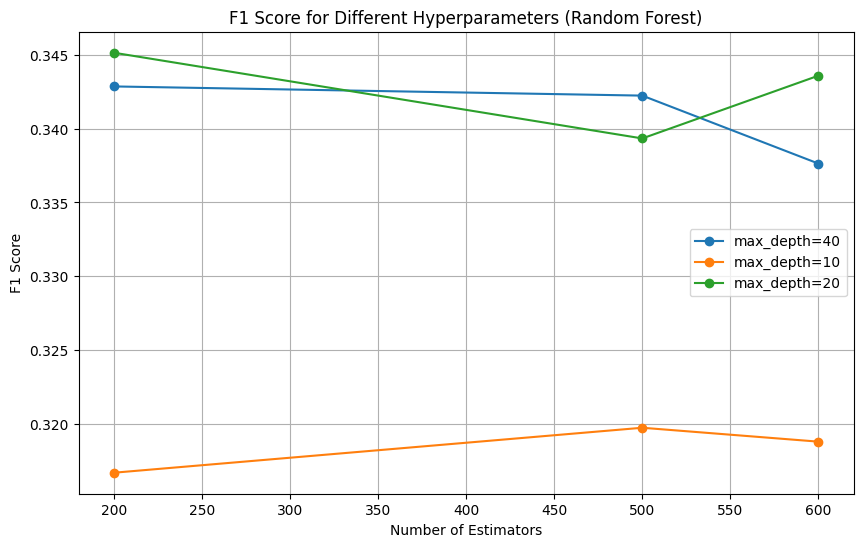

In [ ]:
plot_hyperparameters_RF(f1_scores)

Original

In [ ]:
def perform_RF(X_train, y_train, X_val, y_val):
    # Fixed parameters
    n_estimators = 200
    max_depth = 20

    # Train the model with the fixed parameters
    clf = OneVsRestClassifier(RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth))
    clf.fit(X_train, y_train)
    y_val_pred = clf.predict(X_val)

    # Create a classification report
    report = classification_report(y_val, y_val_pred, zero_division=1)
    return report

In [ ]:
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_original['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.07      0.14        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.03      0.07       177
           6       0.85      0.07      0.12       261
           7       1.00      0.00      0.00         6
           8       0.81      0.42      0.55       912
           9       1.00      0.04      0.07        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.50      0.01      0.02       131
          13       1.00      0.00      0.00         1
          14       0.91      0.11      0.19       288
          15       0.87      0.40      0.55       539
          16       1.00      0.16      0.27       113
          17       0.90    

EDA 60%

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_train_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_eda_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.11      0.20        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.03      0.05       177
           6       0.83      0.06      0.11       261
           7       1.00      0.00      0.00         6
           8       0.82      0.40      0.54       912
           9       1.00      0.04      0.07        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.50      0.01      0.02       131
          13       1.00      0.00      0.00         1
          14       0.95      0.12      0.22       288
          15       0.88      0.40      0.55       539
          16       1.00      0.16      0.27       113
          17       0.89    

Backtranslation (Spanish) 60%

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_train_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_bt_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.07      0.14        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.03      0.07       177
           6       0.77      0.08      0.14       261
           7       1.00      0.00      0.00         6
           8       0.83      0.39      0.53       912
           9       1.00      0.04      0.07        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.50      0.01      0.02       131
          13       1.00      0.00      0.00         1
          14       0.94      0.11      0.20       288
          15       0.84      0.43      0.57       539
          16       1.00      0.13      0.23       113
          17       0.88    

Backtranslation (Korean) 60%

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_train_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_bt_ko_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.01      0.02       121
           1       1.00      0.07      0.14        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.05      0.10       177
           6       0.80      0.08      0.14       261
           7       1.00      0.00      0.00         6
           8       0.83      0.41      0.55       912
           9       1.00      0.04      0.07        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.50      0.01      0.02       131
          13       1.00      0.00      0.00         1
          14       0.92      0.12      0.22       288
          15       0.86      0.41      0.56       539
          16       1.00      0.18      0.30       113
          17       0.90    

1% Subset

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset01_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset01_original['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.00      0.00       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.76      0.05      0.09       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       1.00      0.00      0.00       288
          15       1.00      0.00      0.00       539
          16       1.00      0.00      0.00       113
          17       0.83    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset01_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset01_eda_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.00      0.00       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.72      0.08      0.15       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       1.00      0.00      0.00       288
          15       0.64      0.01      0.03       539
          16       1.00      0.00      0.00       113
          17       0.85    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset01_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset01_bt_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.01      0.01       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.66      0.09      0.16       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       1.00      0.00      0.00       288
          15       0.71      0.02      0.04       539
          16       1.00      0.00      0.00       113
          17       0.89    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset01_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset01_bt_ko_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.01      0.01       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.66      0.10      0.18       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       1.00      0.00      0.00       288
          15       0.67      0.01      0.02       539
          16       1.00      0.00      0.00       113
          17       0.81    

5% Subset

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset05_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset05_original['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.01      0.02       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.02      0.03       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.80      0.17      0.28       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       0.00      0.00      0.00       288
          15       0.84      0.12      0.21       539
          16       1.00      0.00      0.00       113
          17       0.91    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset05_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset05_eda_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.01      0.02       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       0.80      0.02      0.04       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.78      0.25      0.38       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       1.00      0.00      0.01       288
          15       0.82      0.14      0.24       539
          16       1.00      0.00      0.00       113
          17       0.88    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset05_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset05_bt_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.01      0.02       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.02      0.04       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.77      0.23      0.36       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       1.00      0.00      0.01       288
          15       0.83      0.15      0.25       539
          16       1.00      0.00      0.00       113
          17       0.89    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset05_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset05_bt_ko_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.03      0.05       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.74      0.29      0.41       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       0.67      0.01      0.01       288
          15       0.85      0.18      0.29       539
          16       1.00      0.00      0.00       113
          17       0.90    

10% Subset

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset10_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset10_original['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       0.75      0.02      0.03       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.80      0.27      0.40       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       1.00      0.01      0.01       288
          15       0.90      0.19      0.32       539
          16       1.00      0.00      0.00       113
          17       0.87    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset10_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset10_eda_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.03      0.05       177
           6       1.00      0.00      0.01       261
           7       1.00      0.00      0.00         6
           8       0.78      0.25      0.37       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       1.00      0.00      0.01       288
          15       0.90      0.20      0.32       539
          16       1.00      0.00      0.00       113
          17       0.86    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset10_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset10_bt_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.03      0.05       177
           6       1.00      0.00      0.01       261
           7       1.00      0.00      0.00         6
           8       0.81      0.24      0.37       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       0.50      0.00      0.01       288
          15       0.90      0.21      0.33       539
          16       1.00      0.00      0.00       113
          17       0.85    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset10_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset10_bt_ko_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.03      0.05       177
           6       1.00      0.01      0.02       261
           7       1.00      0.00      0.00         6
           8       0.80      0.27      0.41       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       1.00      0.01      0.01       288
          15       0.92      0.20      0.33       539
          16       1.00      0.00      0.00       113
          17       0.87    

20% Subset

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset20_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset20_original['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.02      0.04        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.02      0.03       177
           6       0.89      0.03      0.06       261
           7       1.00      0.00      0.00         6
           8       0.85      0.27      0.41       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       0.87      0.05      0.09       288
          15       0.88      0.31      0.45       539
          16       1.00      0.01      0.02       113
          17       0.91    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset20_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset20_eda_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.02      0.04        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.02      0.04       177
           6       0.82      0.03      0.07       261
           7       1.00      0.00      0.00         6
           8       0.83      0.29      0.43       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       0.69      0.03      0.06       288
          15       0.84      0.32      0.47       539
          16       1.00      0.02      0.03       113
          17       0.90    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset20_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset20_bt_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.03      0.05       177
           6       0.86      0.05      0.09       261
           7       1.00      0.00      0.00         6
           8       0.85      0.28      0.42       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       0.77      0.03      0.07       288
          15       0.85      0.32      0.47       539
          16       1.00      0.02      0.03       113
          17       0.90    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset20_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset20_bt_ko_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.04      0.07        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.02      0.03       177
           6       0.82      0.03      0.07       261
           7       1.00      0.00      0.00         6
           8       0.82      0.29      0.43       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       0.80      0.03      0.05       288
          15       0.87      0.34      0.48       539
          16       1.00      0.01      0.02       113
          17       0.90    

30% Subset

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset30_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset30_original['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.04      0.07        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.03      0.05       177
           6       0.78      0.03      0.05       261
           7       1.00      0.00      0.00         6
           8       0.83      0.33      0.47       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       1.00      0.03      0.06       288
          15       0.87      0.32      0.47       539
          16       1.00      0.02      0.03       113
          17       0.90    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset30_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset30_eda_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.01      0.02       121
           1       1.00      0.04      0.07        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.02      0.04       177
           6       0.90      0.03      0.07       261
           7       1.00      0.00      0.00         6
           8       0.84      0.35      0.49       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       1.00      0.04      0.07       288
          15       0.87      0.33      0.48       539
          16       1.00      0.04      0.07       113
          17       0.88    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset30_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset30_bt_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.01      0.02       121
           1       1.00      0.04      0.07        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.03      0.05       177
           6       0.89      0.03      0.06       261
           7       1.00      0.00      0.00         6
           8       0.82      0.33      0.47       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       0.94      0.06      0.10       288
          15       0.84      0.32      0.46       539
          16       1.00      0.04      0.07       113
          17       0.90    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/bert_embeddings_subset30_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset30_bt_ko_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.01      0.02       121
           1       1.00      0.05      0.10        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.03      0.05       177
           6       0.67      0.03      0.06       261
           7       1.00      0.00      0.00         6
           8       0.81      0.35      0.48       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       0.95      0.07      0.12       288
          15       0.89      0.34      0.50       539
          16       1.00      0.06      0.12       113
          17       0.91    

## Roberta

Hyperparameter Tuning

In [ ]:
val_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_val.pkl'

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_train_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_original['labels'], val_df['labels'])
f1_scores = hyperparam_perform_RF(X_train, y_train, X_val, y_val)

Parameters: n_estimators= 200 , max_depth= 20  --> F1 score: 0.35511533324328787
Parameters: n_estimators= 200 , max_depth= 30  --> F1 score: 0.3578272027373824
Parameters: n_estimators= 200 , max_depth= 40  --> F1 score: 0.3527351312412768
Parameters: n_estimators= 300 , max_depth= 20  --> F1 score: 0.35744000720363783
Parameters: n_estimators= 300 , max_depth= 30  --> F1 score: 0.35461107859469027
Parameters: n_estimators= 300 , max_depth= 40  --> F1 score: 0.35353803670853784
Best parameters: n_estimators= 200 , max_depth= 30


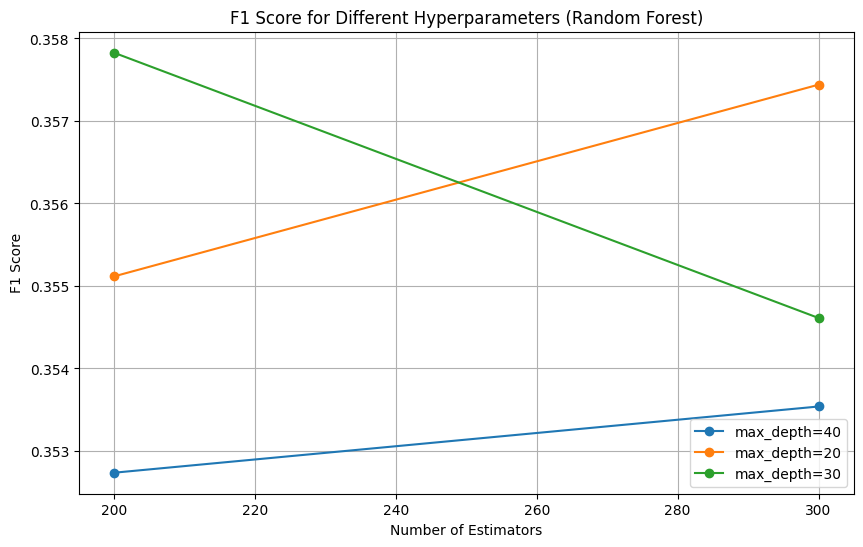

In [ ]:
plot_hyperparameters_RF(f1_scores)

Original

In [ ]:
def perform_RF(X_train, y_train, X_val, y_val):
    # Fixed parameters
    n_estimators = 200
    max_depth = 30

    # Train the model with the fixed parameters
    clf = OneVsRestClassifier(RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth))
    clf.fit(X_train, y_train)
    y_val_pred = clf.predict(X_val)

    # Create a classification report
    report = classification_report(y_val, y_val_pred, zero_division=1)
    return report

In [ ]:
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_original['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.86      0.05      0.09       121
           1       1.00      0.18      0.31        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       0.95      0.12      0.21       177
           6       0.88      0.06      0.11       261
           7       1.00      0.00      0.00         6
           8       0.82      0.42      0.56       912
           9       1.00      0.04      0.07        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.50      0.01      0.02       131
          13       1.00      0.00      0.00         1
          14       0.93      0.14      0.24       288
          15       0.86      0.41      0.55       539
          16       1.00      0.06      0.12       113
          17       0.91    

EDA 60%

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_train_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_eda_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.07      0.12       121
           1       1.00      0.15      0.25        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.12      0.22       177
           6       0.82      0.05      0.10       261
           7       1.00      0.00      0.00         6
           8       0.81      0.39      0.52       912
           9       1.00      0.04      0.07        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.50      0.01      0.02       131
          13       1.00      0.00      0.00         1
          14       0.93      0.15      0.25       288
          15       0.84      0.41      0.55       539
          16       1.00      0.07      0.13       113
          17       0.90    

Backtranslation (Spanish) 60%

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_train_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_bt_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.88      0.06      0.11       121
           1       1.00      0.16      0.28        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.12      0.21       177
           6       0.76      0.05      0.09       261
           7       1.00      0.00      0.00         6
           8       0.82      0.40      0.53       912
           9       1.00      0.04      0.07        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.50      0.01      0.02       131
          13       1.00      0.00      0.00         1
          14       0.93      0.15      0.26       288
          15       0.86      0.43      0.57       539
          16       1.00      0.07      0.13       113
          17       0.92    

Backtranslation (Korean) 60%

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_train_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, train_bt_ko_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.06      0.11       121
           1       1.00      0.22      0.36        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.12      0.22       177
           6       0.79      0.04      0.08       261
           7       1.00      0.00      0.00         6
           8       0.82      0.42      0.55       912
           9       1.00      0.04      0.07        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       0.50      0.01      0.02       131
          13       1.00      0.00      0.00         1
          14       0.93      0.15      0.26       288
          15       0.85      0.39      0.54       539
          16       1.00      0.13      0.23       113
          17       0.92    

1% Subset

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset01_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset01_original['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.01      0.02       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.63      0.05      0.09       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       1.00      0.00      0.00       288
          15       0.79      0.06      0.10       539
          16       1.00      0.00      0.00       113
          17       0.95    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset01_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset01_eda_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.02      0.03       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.72      0.06      0.10       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       1.00      0.00      0.00       288
          15       0.76      0.09      0.16       539
          16       1.00      0.00      0.00       113
          17       0.90    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset01_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset01_bt_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.02      0.04       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.67      0.05      0.10       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       1.00      0.00      0.00       288
          15       0.76      0.08      0.15       539
          16       1.00      0.00      0.00       113
          17       0.88    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset01_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset01_bt_ko_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.02      0.04       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.90      0.07      0.12       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       1.00      0.00      0.00       288
          15       0.71      0.08      0.14       539
          16       1.00      0.00      0.00       113
          17       0.93    

5% Subset

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset05_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset05_original['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.05      0.09       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.80      0.22      0.34       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       1.00      0.00      0.00       288
          15       0.87      0.13      0.23       539
          16       1.00      0.00      0.00       113
          17       0.95    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset05_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset05_eda_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.05      0.10       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.81      0.24      0.37       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       1.00      0.00      0.01       288
          15       0.85      0.17      0.29       539
          16       1.00      0.00      0.00       113
          17       0.90    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset05_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset05_bt_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.05      0.09       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.84      0.25      0.39       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       0.67      0.01      0.01       288
          15       0.85      0.16      0.27       539
          16       1.00      0.00      0.00       113
          17       0.91    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset05_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset05_bt_ko_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.06      0.12       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.81      0.28      0.42       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       0.67      0.01      0.01       288
          15       0.85      0.15      0.25       539
          16       1.00      0.00      0.00       113
          17       0.91    

10% Subset

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset10_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset10_original['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.00      0.00        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.07      0.14       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.79      0.23      0.35       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       0.50      0.01      0.01       288
          15       0.87      0.20      0.32       539
          16       0.00      0.00      0.00       113
          17       0.93    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset10_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset10_eda_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.02      0.04        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.08      0.15       177
           6       1.00      0.00      0.01       261
           7       1.00      0.00      0.00         6
           8       0.84      0.23      0.36       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.01      0.02       131
          13       1.00      0.00      0.00         1
          14       0.75      0.01      0.02       288
          15       0.86      0.20      0.33       539
          16       1.00      0.00      0.00       113
          17       0.92    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset10_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset10_bt_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.02      0.04        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.09      0.17       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.83      0.21      0.34       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.01      0.02       131
          13       1.00      0.00      0.00         1
          14       0.57      0.01      0.03       288
          15       0.89      0.22      0.35       539
          16       1.00      0.00      0.00       113
          17       0.92    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset10_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset10_bt_ko_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.04      0.07        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.08      0.16       177
           6       1.00      0.00      0.00       261
           7       1.00      0.00      0.00         6
           8       0.84      0.27      0.41       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.01      0.02       131
          13       1.00      0.00      0.00         1
          14       0.83      0.02      0.03       288
          15       0.89      0.20      0.33       539
          16       0.00      0.00      0.00       113
          17       0.93    

20% Subset

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset20_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset20_original['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       121
           1       1.00      0.02      0.04        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.08      0.15       177
           6       1.00      0.02      0.04       261
           7       1.00      0.00      0.00         6
           8       0.86      0.26      0.40       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       0.91      0.03      0.07       288
          15       0.85      0.29      0.43       539
          16       1.00      0.01      0.02       113
          17       0.95    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset20_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset20_eda_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.67      0.02      0.03       121
           1       1.00      0.05      0.10        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.07      0.14       177
           6       0.75      0.01      0.02       261
           7       1.00      0.00      0.00         6
           8       0.86      0.28      0.42       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       0.73      0.04      0.07       288
          15       0.84      0.33      0.47       539
          16       1.00      0.01      0.02       113
          17       0.93    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset20_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset20_bt_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       121
           1       1.00      0.04      0.07        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.08      0.16       177
           6       0.82      0.03      0.07       261
           7       1.00      0.00      0.00         6
           8       0.81      0.27      0.40       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       0.77      0.03      0.07       288
          15       0.83      0.31      0.45       539
          16       1.00      0.01      0.02       113
          17       0.93    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset20_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset20_bt_ko_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.00      0.00       121
           1       1.00      0.04      0.07        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.09      0.17       177
           6       1.00      0.02      0.03       261
           7       1.00      0.00      0.00         6
           8       0.83      0.27      0.40       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       0.75      0.03      0.06       288
          15       0.86      0.31      0.45       539
          16       1.00      0.03      0.05       113
          17       0.93    

30% Subset

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset30_original.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset30_original['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.02      0.03       121
           1       1.00      0.04      0.07        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.07      0.14       177
           6       1.00      0.02      0.04       261
           7       1.00      0.00      0.00         6
           8       0.83      0.34      0.48       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       0.92      0.04      0.07       288
          15       0.87      0.33      0.48       539
          16       1.00      0.01      0.02       113
          17       0.94    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset30_eda_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset30_eda_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.02      0.05       121
           1       1.00      0.09      0.17        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.10      0.18       177
           6       1.00      0.01      0.02       261
           7       1.00      0.00      0.00         6
           8       0.81      0.32      0.46       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       0.88      0.05      0.09       288
          15       0.86      0.34      0.48       539
          16       1.00      0.02      0.03       113
          17       0.93    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset30_bt_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset30_bt_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.02      0.05       121
           1       1.00      0.09      0.17        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.10      0.18       177
           6       1.00      0.01      0.02       261
           7       1.00      0.00      0.00         6
           8       0.83      0.32      0.47       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       0.89      0.06      0.11       288
          15       0.86      0.33      0.48       539
          16       1.00      0.01      0.02       113
          17       0.93    

In [ ]:
train_pickle_path = '/content/gdrive/My Drive/MSc Project/roberta_embeddings_subset30_bt_ko_60perc.pkl'
X_train, y_train, X_val, y_val = load_embeddings_and_labels(train_pickle_path, val_pickle_path, subset30_bt_ko_60perc['labels'], val_df['labels'])
report = perform_RF(X_train, y_train, X_val, y_val)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.02      0.03       121
           1       1.00      0.07      0.14        55
           2       1.00      0.00      0.00        16
           3       1.00      0.00      0.00        66
           4       1.00      0.00      0.00         2
           5       1.00      0.10      0.18       177
           6       1.00      0.02      0.04       261
           7       1.00      0.00      0.00         6
           8       0.82      0.34      0.48       912
           9       1.00      0.00      0.00        28
          10       1.00      1.00      1.00         0
          11       1.00      0.00      0.00        49
          12       1.00      0.00      0.00       131
          13       1.00      0.00      0.00         1
          14       0.90      0.07      0.12       288
          15       0.87      0.31      0.46       539
          16       1.00      0.04      0.07       113
          17       0.93    